# 상품별 inflow 운영 전략 진단 분석

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy.stats import chi2_contingency
from IPython.display import display

available_fonts = {font.name for font in fm.fontManager.ttflist}
for candidate in ["Malgun Gothic", "AppleGothic", "NanumGothic", "Arial Unicode MS"]:
    if candidate in available_fonts:
        plt.rcParams["font.family"] = candidate
        break

plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [2]:
base_dir = Path.cwd()

def leading_number(name: str):
    digits = ""
    for char in Path(name).stem:
        if char.isdigit():
            digits += char
        else:
            break
    return int(digits) if digits else None

def find_csv(index: int) -> Path:
    candidates = sorted(
        [Path(name) for name in os.listdir(base_dir) if name.endswith(".csv") and leading_number(name) == index]
    )
    if not candidates:
        raise FileNotFoundError(f"{index}번 CSV 파일을 찾지 못했습니다.")
    return candidates[0]

target_files = {
    "file_1": find_csv(1),
    "file_2": find_csv(2),
    "file_3": find_csv(3),
    "file_4": find_csv(4),
    "file_6": find_csv(6),
    "file_9": find_csv(9),
}

dfs = {key: pd.read_csv(path) for key, path in target_files.items()}

numeric_columns = {
    "file_1": [
        "CONTRACT_COUNT", "CONSULT_REQUEST_COUNT", "REGISTEND_COUNT", "OPEN_COUNT", "PAYEND_COUNT",
        "REGISTEND_CVR", "OPEN_CVR", "PAYEND_CVR", "AVG_NET_SALES", "TOTAL_NET_SALES"
    ],
    "file_2": ["CONTRACT_COUNT", "PAYEND_COUNT", "AVG_NET_SALES", "AVG_POLICY_AMOUNT"],
    "file_3": [
        "TOTAL_COUNT", "CONSULT_REQUEST_COUNT", "SUBSCRIPTION_COUNT", "REGISTEND_COUNT", "OPEN_COUNT", "PAYEND_COUNT",
        "CVR_CONSULT_REQUEST", "CVR_SUBSCRIPTION", "CVR_REGISTEND", "CVR_OPEN", "CVR_PAYEND", "OVERALL_CVR"
    ],
    "file_4": [
        "CONTRACT_COUNT", "REGISTEND_COUNT", "OPEN_COUNT", "PAYEND_COUNT", "OPEN_CVR", "PAYEND_CVR",
        "AVG_NET_SALES", "TOTAL_NET_SALES"
    ],
    "file_6": ["CONTRACT_COUNT", "OPEN_COUNT", "PAYEND_COUNT", "OPEN_CVR", "PAYEND_CVR", "AVG_NET_SALES", "AVG_POLICY_AMOUNT"],
    "file_9": [
        "CALL_COUNT", "AVG_BILL_SECOND", "AVG_BILL_MINUTE", "MAX_BILL_SECOND", "TOTAL_BILL_SECOND",
        "CONNECTED_COUNT", "UNCONNECTED_COUNT", "CONNECTION_RATE"
    ],
}

processed_dfs = {}
for key, df in dfs.items():
    temp = df.copy()
    if "YEAR_MONTH" in temp.columns:
        temp["YEAR_MONTH"] = pd.to_datetime(temp["YEAR_MONTH"], errors="coerce")
    for col in numeric_columns.get(key, []):
        if col in temp.columns:
            temp[col] = pd.to_numeric(temp[col], errors="coerce")
    processed_dfs[key] = temp

df1 = processed_dfs["file_1"].copy()
df2 = processed_dfs["file_2"].copy()
df3 = processed_dfs["file_3"].copy()
df4 = processed_dfs["file_4"].copy()
df6 = processed_dfs["file_6"].copy()
df9 = processed_dfs["file_9"].copy()

analysis_start = pd.Timestamp("2023-05-01")
analysis_end = pd.Timestamp("2026-03-01")

def filter_period(df, start, end):
    if "YEAR_MONTH" not in df.columns:
        return df.copy()
    return df[df["YEAR_MONTH"].between(start, end)].copy()

df1 = filter_period(df1, analysis_start, analysis_end)
df2 = filter_period(df2, analysis_start, analysis_end)
df3 = filter_period(df3, analysis_start, analysis_end)
df4 = filter_period(df4, analysis_start, analysis_end)
df6 = filter_period(df6, analysis_start, analysis_end)
df9 = filter_period(df9, analysis_start, analysis_end)

exclude_categories = ["상조", "부동산", "이사", "다이렉트자보"]
df1 = df1[~df1["MAIN_CATEGORY_NAME"].isin(exclude_categories)].copy()
df3 = df3[~df3["MAIN_CATEGORY_NAME"].isin(exclude_categories)].copy()
df4 = df4[~df4["MAIN_CATEGORY_NAME"].isin(exclude_categories)].copy()
df9 = df9[~df9["MAIN_CATEGORY_NAME"].isin(exclude_categories)].copy()

## 0. 분석 목적

이 분석의 목적은 단순히 "어떤 상품이 잘 팔리는가"를 보는 것이 아니라,  
**현재 상품별 inflow 운영 전략이 매출 효율 관점에서 최선인지 점검하고, 어디를 조정하면 얼마의 추가매출 기회가 있는지를 추정하는 것**이다.

즉, 이 분석은 전통적인 원인 규명형 분석보다는 **의사결정형 · 최적화형 · 임팩트 추정형 분석**에 가깝다.

이번 노트북의 앞부분에서는 아래 두 가지를 먼저 확인한다.

1. 현재 상품군별 성과 차이가 실제로 존재하는가?
2. 현재 운영 구조를 상품×inflow 관점으로 나눠서 볼 필요가 있는가?

해석 범위도 함께 명확히 한다.

- 본 분석은 고객 단위 행동 로그가 아니라 월 단위 집계 데이터 기반 분석이다.
- 따라서 개별 고객 이탈 원인을 직접 규명하기보다는, 운영 구조의 성과 차이와 최적화 여지를 진단하는 데 초점을 둔다.
- 이후 단계에서는 효율 차이, 배분 미스매치, 잠재 매출 기회를 차례로 확장해 본다.

## 1. 문제 정의

### 핵심 질문
**현재 이루어지고 있는 상품별 inflow 운영 구조는 매출 효율 관점에서 최선에 가까운가?**

### 문제의식
여러 상품은 공통된 inflow 경로들을 상당 부분 공유하고 있다.  
그러나 상품별 inflow 구성과 성과는 동일하지 않을 수 있다.  
즉, 모든 상품에 동일한 inflow 운영 구조를 적용하는 것이 최선이라고 보기 어렵고, 상품별로 상대적으로 더 적합한 inflow 묶음이 존재할 가능성이 있다.

다만 현재 데이터에는 inflow 비용 정보가 없으므로, 이 단계에서 확인하려는 것은 **비용 효율**이 아니라 **구조 차이의 존재 여부**이다.  
따라서 먼저 상품별 inflow 구성이 실제로 어떻게 다른지 확인하고, 이후 단계에서 그 차이가 성과 효율 차이와 연결되는지 검토한다.

이번 단계에서는 아래 네 가지 중 앞의 두 가지를 우선 확인한다.

1. 현재 분석에서 보는 기본 퍼널 흐름은 무엇인가?
2. 상품별 inflow 구성은 서로 유사한가, 아니면 차이가 존재하는가?
3. 이후 단계에서 상품×inflow 성과 효율 차이를 확인할 수 있는가?
4. 이후 단계에서 배분과 효율의 미스매치, 잠재 추가매출을 추정할 수 있는가?

여기서는 문제를 결론내리는 단계가 아니라, **왜 상품×inflow 단위의 운영 진단이 필요한지 근거를 제시하는 단계**로 본다.

- 분석 기간: 2023-05 ~ 2026-03
- 제외 상품군: 상조, 부동산, 이사, 다이렉트자보
  이유: 공통 분석기간 내 관측 개월 수와 물량이 매우 작거나, 메인 비교축에서 구조적으로 해석이 불안정하기 때문이다.
- `재인입`은 최초 유입 채널과 성격이 달라, 메인 inflow mix 비교에서는 제외하고 후속 해석에서 별도로 본다.

### 1-1. 현재 분석에서 보는 기본 퍼널 흐름

이번 분석에서 메인 퍼널은 `3번.csv`의 상품군별 집계 퍼널을 기준으로 본다.  
해석 편의상 주요 단계는 아래처럼 정리한다.

`유입(TOTAL_COUNT) -> 상담요청(CONSULT_REQUEST_COUNT) -> 접수(REGISTEND_COUNT) -> 개통(OPEN_COUNT) -> 지급(PAYEND_COUNT)`

즉, 이후 분석에서 `consult_request`는 lead에 가까운 단계로 해석하고, `payend`를 최종 성과 단계로 본다.

In [3]:
funnel_stage_summary = pd.DataFrame(
    {
        "stage": ["유입", "상담요청", "접수", "개통", "지급"],
        "count": [
            df3["TOTAL_COUNT"].sum(),
            df3["CONSULT_REQUEST_COUNT"].sum(),
            df3["REGISTEND_COUNT"].sum(),
            df3["OPEN_COUNT"].sum(),
            df3["PAYEND_COUNT"].sum(),
        ],
    }
)
funnel_stage_summary["previous_stage"] = funnel_stage_summary["count"].shift(1)
funnel_stage_summary["stage_cvr"] = np.where(
    funnel_stage_summary["previous_stage"].notna() & (funnel_stage_summary["previous_stage"] > 0),
    funnel_stage_summary["count"] / funnel_stage_summary["previous_stage"] * 100,
    np.nan,
)
funnel_stage_summary["overall_share"] = funnel_stage_summary["count"] / funnel_stage_summary.loc[0, "count"] * 100

display(
    funnel_stage_summary.style.format(
        {
            "count": "{:}",
            "stage_cvr": "{:}",
            "overall_share": "{:,}",
        },
        na_rep="-"
    )
)

,stage,count,previous_stage,stage_cvr,overall_share
0,유입,6480288,-,-,100.0
1,상담요청,2524485,6480288.000000,38.95637045760929,38.95637045760929
2,접수,2509130,2524485.000000,99.3917571306623,38.7194211121481
3,개통,2078430,2509130.000000,82.83468772044493,32.073111565411914
4,지급,2082176,2078430.000000,100.18023219449297,32.130917638228425


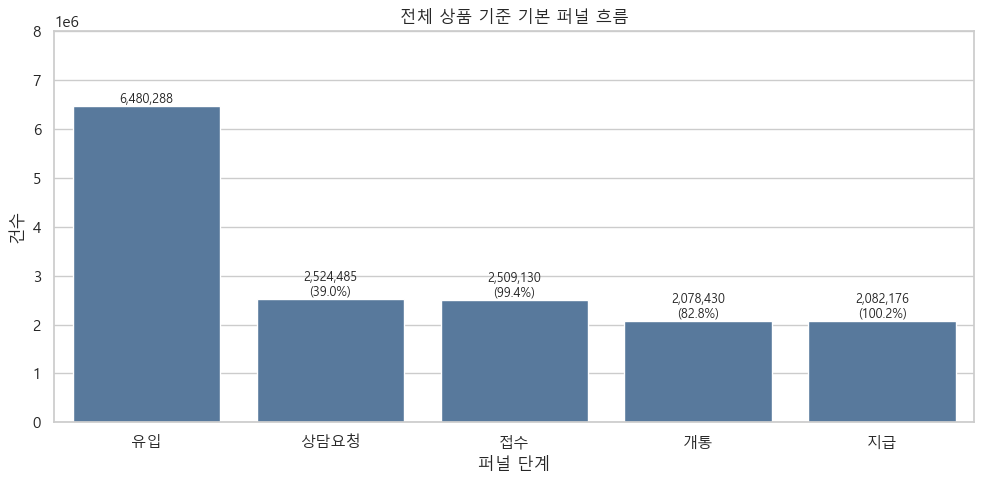

In [4]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=funnel_stage_summary, x="stage", y="count", color="#4C78A8")

for i, row in funnel_stage_summary.iterrows():
    label = f"{row['count']:,.0f}"
    if pd.notna(row["stage_cvr"]):
        label += f"\n({row['stage_cvr']:.1f}%)"
    ax.text(i, row["count"], label, ha="center", va="bottom", fontsize=9)

ax.set_title("전체 상품 기준 기본 퍼널 흐름")
ax.set_xlabel("퍼널 단계")
ax.set_ylabel("건수")
ax.set_ylim(0, 8000000)

plt.tight_layout()
plt.show()

위 퍼널은 이후 분석에서 성과를 해석하는 공통 프레임이다.  
즉, 이후 상품×inflow 분석은 결국 어떤 상품이 더 많은 유입을 만들고 있는지뿐 아니라, 그 유입이 상담요청과 최종 지급까지 얼마나 효율적으로 이어지는지를 비교하는 구조로 이어진다.

전체적인 퍼널의 흐름을 보면 유입에서 상담요청까지만 잘 이어진다면 대부분의 유저는 payend(지급)까지 이어지는 것으로 보인다.
상품별로 상담요청으로 잘 이끌어 나가게하는 inflow , receive가 있지않을까?

### 1-2. 상품별 inflow mix는 동일한가?

이제 `4번.csv`의 `INFLOW_PATH_NAME`을 이용해, 상품별 inflow 구성이 서로 유사한지 확인한다.  
여기서 보고 싶은 것은 성과 우열이 아니라 **현재 상품별 inflow가 어떤 비율로 섞여 있는가**이다.

이번 비교에서는 `재인입`을 제외한다. `재인입`은 기존 유입 고객의 재접촉/재유입 성격으로 해석될 가능성이 커서, 최초 유입 채널과 같은 수준의 전략 inflow로 직접 비교하기에는 성격이 다르기 때문이다.

- 같은 상품 안에서 inflow 비중이 여러 경로로 분산되어 있으면 혼재형 구조로 볼 수 있다.
- 특정 inflow 비중이 매우 높으면 집중형 구조로 볼 수 있다.
- 상품별 구성 차이가 존재한다면, 이후 성과 효율 비교도 상품×inflow 단위로 보는 것이 타당해진다.
- 다만 혼재되어 있다는 사실만으로 현재 전략이 비효율적이라고 판단하지는 않는다.

In [5]:
product_inflow_mix = (
    df4.groupby(["MAIN_CATEGORY_NAME", "INFLOW_PATH_NAME"], dropna=False)["CONTRACT_COUNT"]
    .sum()
    .reset_index()
)
product_inflow_mix["INFLOW_PATH_NAME"] = product_inflow_mix["INFLOW_PATH_NAME"].fillna("미분류")

# 재인입은 기존 유입 고객의 재접촉 성격일 가능성이 커서,
# 메인 전략 inflow mix 비교에서는 제외한다.
strategic_inflow_mix = product_inflow_mix[product_inflow_mix["INFLOW_PATH_NAME"] != "재인입"].copy()

top_inflows = (
    strategic_inflow_mix.groupby("INFLOW_PATH_NAME")["CONTRACT_COUNT"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .index
)

mix_for_plot = strategic_inflow_mix.copy()
mix_for_plot["inflow_group"] = np.where(
    mix_for_plot["INFLOW_PATH_NAME"].isin(top_inflows),
    mix_for_plot["INFLOW_PATH_NAME"],
    "기타"
)

mix_for_plot = (
    mix_for_plot.groupby(["MAIN_CATEGORY_NAME", "inflow_group"], as_index=False)["CONTRACT_COUNT"]
    .sum()
)
mix_for_plot["contract_share"] = mix_for_plot.groupby("MAIN_CATEGORY_NAME")["CONTRACT_COUNT"].transform(lambda s: s / s.sum() * 100)

mix_pivot = (
    mix_for_plot.pivot(index="MAIN_CATEGORY_NAME", columns="inflow_group", values="contract_share")
    .fillna(0)
)

product_order = (
    strategic_inflow_mix.groupby("MAIN_CATEGORY_NAME")["CONTRACT_COUNT"]
    .sum()
    .sort_values(ascending=False)
    .index
)
mix_pivot = mix_pivot.reindex(product_order)

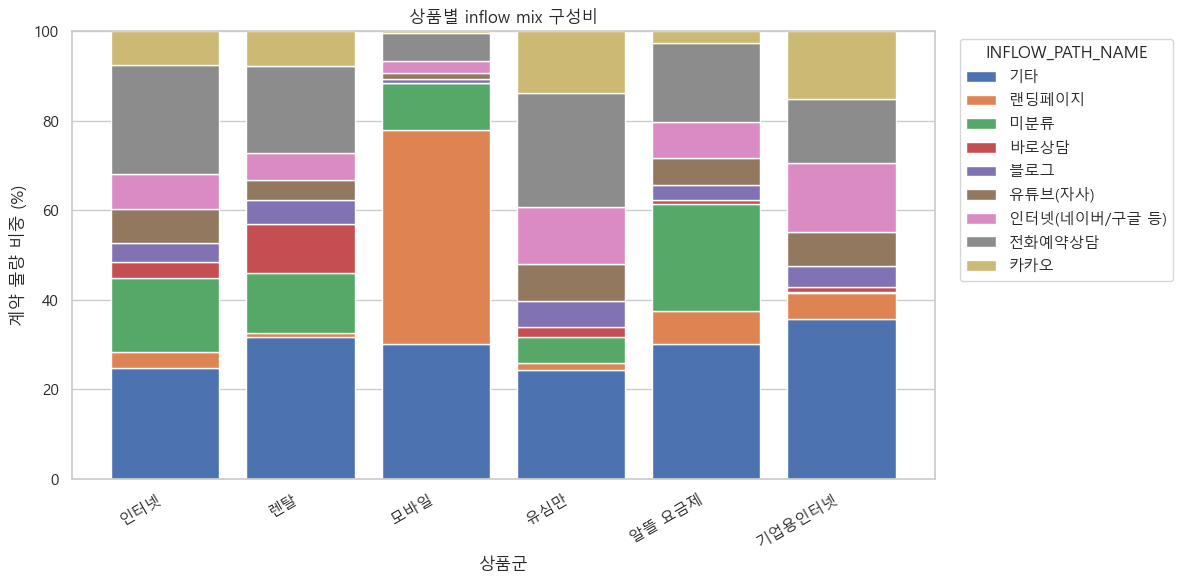

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(mix_pivot))

for col in mix_pivot.columns:
    ax.bar(mix_pivot.index, mix_pivot[col], bottom=bottom, label=col)
    bottom += mix_pivot[col].values

ax.set_title("상품별 inflow mix 구성비")
ax.set_xlabel("상품군")
ax.set_ylabel("계약 물량 비중 (%)")
ax.set_ylim(0, 100)
ax.legend(title="INFLOW_PATH_NAME", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [7]:
inflow_concentration = (
    strategic_inflow_mix.groupby(["MAIN_CATEGORY_NAME", "INFLOW_PATH_NAME"], dropna=False)["CONTRACT_COUNT"]
    .sum()
    .reset_index()
)
inflow_concentration["INFLOW_PATH_NAME"] = inflow_concentration["INFLOW_PATH_NAME"].fillna("미분류")
inflow_concentration["share"] = inflow_concentration.groupby("MAIN_CATEGORY_NAME")["CONTRACT_COUNT"].transform(lambda s: s / s.sum())

concentration_summary = (
    inflow_concentration.sort_values(["MAIN_CATEGORY_NAME", "share"], ascending=[True, False])
    .groupby("MAIN_CATEGORY_NAME")
    .apply(
        lambda g: pd.Series(
            {
                "top1_inflow": g.iloc[0]["INFLOW_PATH_NAME"],
                "top1_share": g.iloc[0]["share"] * 100,
                "top3_share": g.head(3)["share"].sum() * 100,
                "inflow_count": g["INFLOW_PATH_NAME"].nunique(),
            }
        )
    )
    .reset_index()
    .sort_values("top1_share", ascending=False)
)

display(
    concentration_summary.style.format(
        {
            "top1_share": "{:,.1f}%",
            "top3_share": "{:,.1f}%",
            "inflow_count": "{:,.0f}",
        }
    )
)

C:\Users\rhals\AppData\Local\Temp\ipykernel_25248\498015961.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,MAIN_CATEGORY_NAME,top1_inflow,top1_share,top3_share,inflow_count
2,모바일,랜딩페이지,47.8%,76.5%,35
4,유심만,전화예약상담,25.3%,52.0%,40
5,인터넷,전화예약상담,24.4%,48.7%,56
3,알뜰 요금제,미분류,23.9%,49.5%,32
1,렌탈,전화예약상담,19.5%,43.7%,50
0,기업용인터넷,플랫폼,17.8%,48.2%,29


### Step 1 해석 가이드

이 단계에서 바로 말할 수 있는 내용은 다음 정도다.

1. 현재 분석은 `유입 -> 상담요청 -> 접수 -> 개통 -> 지급` 흐름을 공통 퍼널로 본다.
2. 여러 상품은 공통된 inflow 경로를 상당 부분 공유하지만, 상품별 inflow 구성은 완전히 동일하지 않다.
3. 상품별로 inflow의 비중이 매우 다르다
4. 따라서 모든 상품에 동일한 inflow 운영 구조를 적용하는 것이 항상 최선이라고 단정하기 어렵고, 상품×inflow 단위 진단이 필요하다는 근거를 얻을 수 있다.
5. 다만 이 단계에서는 아직 어떤 inflow가 더 효율적인지 판단하지 않고, 구조 차이의 존재 여부만 확인한다.

즉, 이 단계의 결론은 `현재 전략이 비효율적이다`가 아니라, `동일한 운영 구조가 최선인지 점검할 필요가 있다`는 수준이다.  
따라서 다음 단계에서는 `현재 운영 구조 진단`으로 넘어가, 실제로 어떤 상품이 규모를 만들고 있고 어떤 상품이 더 높은 전환 성과와 수익 효율을 보이는지 확인한다.

## 2. 현재 운영 구조 진단

Step1에서 상품별 inflow 구조 차이가 존재함을 확인했다.  
이제 Step2에서는 상품 레벨에서 현재 운영 성과가 어떻게 다른지 먼저 진단한다.

이 단계의 목적은 아래 네 가지를 확인하는 것이다.

1. 현재 어떤 상품이 전체 규모를 만들고 있는가?
2. 어떤 상품이 더 높은 최종 전환 성과를 보이는가?
3. 어떤 상품이 유입 대비 더 높은 순매출 효율을 만드는가?
4. 규모가 큰 상품과 효율이 좋은 상품은 같은가, 아니면 차이가 있는가?

여기서는 아직 inflow별 효율을 판단하지 않고, **상품 단위의 현재 상태**를 먼저 정리한다.

In [8]:
product_funnel_summary = (
    df3.assign(overall_cvr_weighted=df3["OVERALL_CVR"] * df3["TOTAL_COUNT"])
    .groupby("MAIN_CATEGORY_NAME")
    .agg(
        unique_months=("YEAR_MONTH", "nunique"),
        total_volume=("TOTAL_COUNT", "sum"),
        consult_request_count=("CONSULT_REQUEST_COUNT", "sum"),
        registend_count=("REGISTEND_COUNT", "sum"),
        open_count=("OPEN_COUNT", "sum"),
        payend_count=("PAYEND_COUNT", "sum"),
        overall_cvr_weighted_sum=("overall_cvr_weighted", "sum"),
    )
    .reset_index()
)
product_funnel_summary["overall_cvr_wavg"] = np.where(
    product_funnel_summary["total_volume"] > 0,
    product_funnel_summary["overall_cvr_weighted_sum"] / product_funnel_summary["total_volume"],
    np.nan,
)
product_funnel_summary = product_funnel_summary.drop(columns=["overall_cvr_weighted_sum"])

product_sales_summary = (
    df4.groupby("MAIN_CATEGORY_NAME")
    .agg(
        contract_count=("CONTRACT_COUNT", "sum"),
        total_net_sales=("TOTAL_NET_SALES", "sum"),
    )
    .reset_index()
)

step2_summary = (
    product_funnel_summary.merge(product_sales_summary, on="MAIN_CATEGORY_NAME", how="left")
    .assign(
        contract_count=lambda x: x["contract_count"].fillna(0),
        total_net_sales=lambda x: x["total_net_sales"].fillna(0),
        consult_request_rate=lambda x: np.where(x["total_volume"] > 0, x["consult_request_count"] / x["total_volume"] * 100, np.nan),
        sales_per_volume=lambda x: np.where(x["total_volume"] > 0, x["total_net_sales"] / x["total_volume"], np.nan),
        sales_per_lead=lambda x: np.where(x["consult_request_count"] > 0, x["total_net_sales"] / x["consult_request_count"], np.nan),
    )
    .sort_values("total_net_sales", ascending=False)
)

step2_summary

,MAIN_CATEGORY_NAME,unique_months,total_volume,consult_request_count,registend_count,open_count,payend_count,overall_cvr_wavg,contract_count,total_net_sales,consult_request_rate,sales_per_volume,sales_per_lead
5,인터넷,35,4587386,1679961,1754643,1453798,1455796,31.734741,4584578,587415696892,36.621313,128050.200461,349660.317645
1,렌탈,35,1114519,454525,496688,389948,392027,35.173858,1112608,140648733955,40.782167,126196.802347,309441.139552
4,유심만,32,303972,64404,172288,157857,157646,51.861752,302478,51135661437,21.187478,168224.907021,793982.694196
2,모바일,32,397333,285150,66874,60204,60100,15.124912,396040,14409945762,71.766000,36266.672444,50534.616034
3,알뜰 요금제,33,53395,18001,18532,16547,16531,30.960551,52181,3791415049,33.712894,71006.930405,210622.468141
0,기업용인터넷,25,23683,22444,105,76,76,0.320584,22848,18644079,94.768399,787.234683,830.693236


In [9]:
step2_display_columns = [
    "MAIN_CATEGORY_NAME",
    "unique_months",
    "total_volume",
    "consult_request_count",
    "payend_count",
    "overall_cvr_wavg",
    "consult_request_rate",
    "sales_per_volume",
    "sales_per_lead",
    "total_net_sales",
]

display(
    step2_summary[step2_display_columns].style.format(
        {
            "total_volume": "{:,.0f}",
            "consult_request_count": "{:,.0f}",
            "payend_count": "{:,.0f}",
            "overall_cvr_wavg": "{:,.2f}",
            "consult_request_rate": "{:,.2f}",
            "sales_per_volume": "{:,.0f}",
            "sales_per_lead": "{:,.0f}",
            "total_net_sales": "{:,.0f}",
        }
    )
)

,MAIN_CATEGORY_NAME,unique_months,total_volume,consult_request_count,payend_count,overall_cvr_wavg,consult_request_rate,sales_per_volume,sales_per_lead,total_net_sales
5,인터넷,35,"4,587,386","1,679,961","1,455,796",31.73,36.62,"128,050","349,660","587,415,696,892"
1,렌탈,35,"1,114,519","454,525","392,027",35.17,40.78,"126,197","309,441","140,648,733,955"
4,유심만,32,"303,972","64,404","157,646",51.86,21.19,"168,225","793,983","51,135,661,437"
2,모바일,32,"397,333","285,150","60,100",15.12,71.77,"36,267","50,535","14,409,945,762"
3,알뜰 요금제,33,"53,395","18,001","16,531",30.96,33.71,"71,007","210,622","3,791,415,049"
0,기업용인터넷,25,"23,683","22,444",76,0.32,94.77,787,831,"18,644,079"


위 표는 상품별 현재 운영 상태를 한 번에 보기 위한 기준표다.  
이번 분석에서는 `CONSULT_REQUEST_COUNT`를 lead에 가까운 단계로 해석하므로, `consult_request_count`는 곧 **상담요청 규모(lead 규모)** 로 읽는다.

핵심 지표의 의미는 다음과 같다.

- `total_volume`: 전체 유입 규모
- `consult_request_count`: 상담요청 규모, 즉 분석상 lead 규모
- `overall_cvr_wavg`: 유입부터 최종 지급까지의 최종 전환 성과
- `sales_per_volume`: 유입 1건당 평균 순매출
- `sales_per_lead`: 상담요청 1건당 평균 순매출
- `total_net_sales`: 전체 순매출 규모

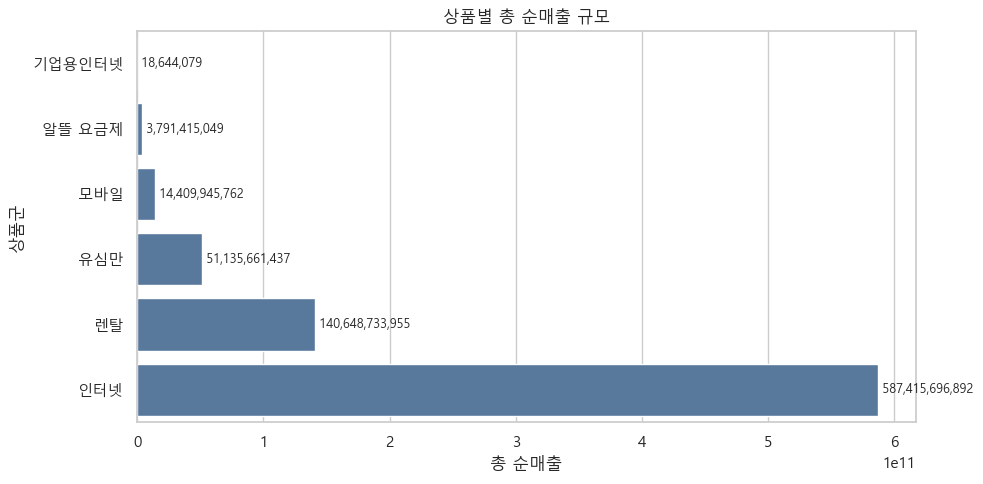

In [10]:
plot_order_sales = step2_summary.sort_values("total_net_sales", ascending=True)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=plot_order_sales, x="total_net_sales", y="MAIN_CATEGORY_NAME", color="#4C78A8")

for i, row in plot_order_sales.reset_index(drop=True).iterrows():
    ax.text(row["total_net_sales"], i, f" {row['total_net_sales']:,.0f}", va="center", fontsize=9)

ax.set_title("상품별 총 순매출 규모")
ax.set_xlabel("총 순매출")
ax.set_ylabel("상품군")

plt.tight_layout()
plt.show()

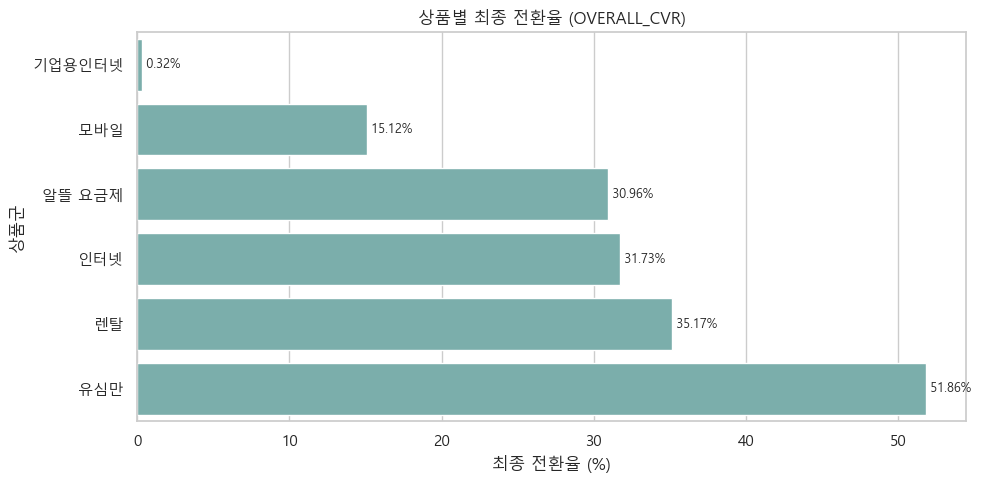

In [11]:
plot_order_cvr = step2_summary.sort_values("overall_cvr_wavg", ascending=True)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=plot_order_cvr, x="overall_cvr_wavg", y="MAIN_CATEGORY_NAME", color="#72B7B2")

for i, row in plot_order_cvr.reset_index(drop=True).iterrows():
    ax.text(row["overall_cvr_wavg"], i, f" {row['overall_cvr_wavg']:.2f}%", va="center", fontsize=9)

ax.set_title("상품별 최종 전환율 (OVERALL_CVR)")
ax.set_xlabel("최종 전환율 (%)")
ax.set_ylabel("상품군")

plt.tight_layout()
plt.show()

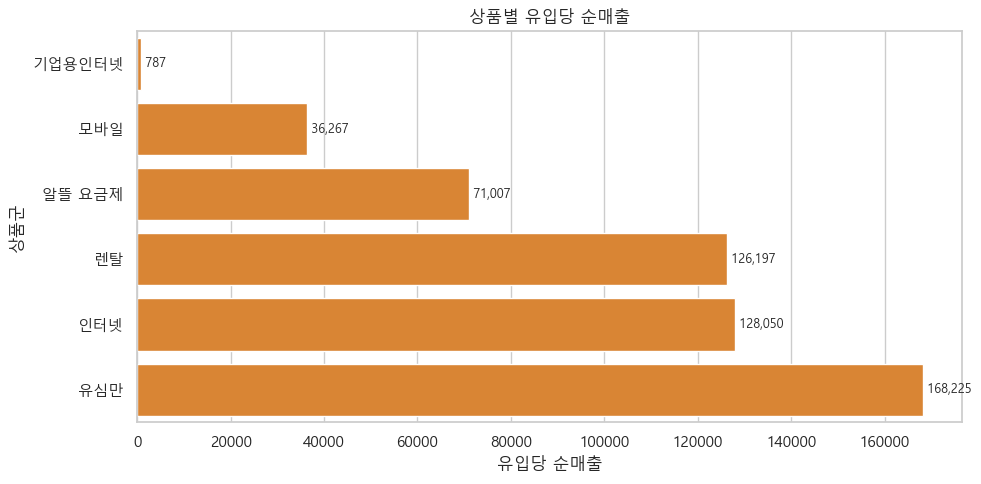

In [12]:
plot_order_eff = step2_summary.sort_values("sales_per_volume", ascending=True)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=plot_order_eff, x="sales_per_volume", y="MAIN_CATEGORY_NAME", color="#F58518")

for i, row in plot_order_eff.reset_index(drop=True).iterrows():
    ax.text(row["sales_per_volume"], i, f" {row['sales_per_volume']:,.0f}", va="center", fontsize=9)

ax.set_title("상품별 유입당 순매출")
ax.set_xlabel("유입당 순매출")
ax.set_ylabel("상품군")

plt.tight_layout()
plt.show()

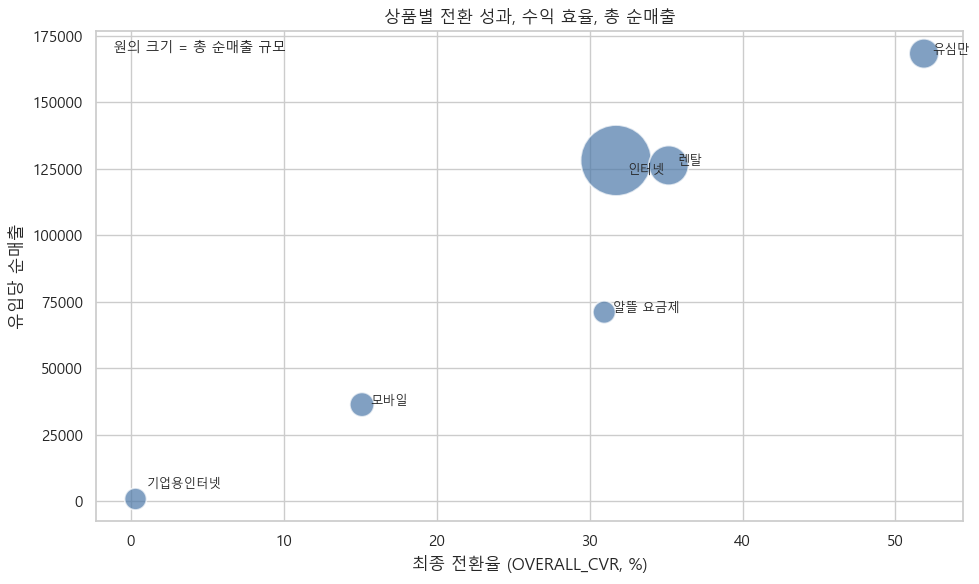

In [13]:
plot_df = step2_summary.copy()

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=plot_df,
    x="overall_cvr_wavg",
    y="sales_per_volume",
    size="total_net_sales",
    sizes=(250, 2600),
    color="#4C78A8",
    alpha=0.7,
    legend=False,
)

label_offsets = {
    "기업용인터넷": {"xytext": (8, 8), "ha": "left"},
    "인터넷": {"xytext": (8, -10), "ha": "left"},
}

for _, row in plot_df.iterrows():
    cfg = label_offsets.get(row["MAIN_CATEGORY_NAME"], {"xytext": (6, 0), "ha": "left"})
    ax.annotate(
        row["MAIN_CATEGORY_NAME"],
        xy=(row["overall_cvr_wavg"], row["sales_per_volume"]),
        xytext=cfg["xytext"],
        textcoords="offset points",
        fontsize=9,
        ha=cfg["ha"],
    )

ax.set_title("상품별 전환 성과, 수익 효율, 총 순매출")
ax.set_xlabel("최종 전환율 (OVERALL_CVR, %)")
ax.set_ylabel("유입당 순매출")
ax.text(
    0.02,
    0.98,
    "원의 크기 = 총 순매출 규모",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
)

plt.tight_layout()
plt.show()

### Step 2 해석 가이드

이 단계에서 확인하고 싶은 핵심은 상품별 현재 운영 성과가 실제로 얼마나 다른지이다.

1. 상품별로 유입 규모와 상담요청 규모는 큰 차이가 있다.
2. 상품별 최종 전환율도 동일하지 않으며, 규모가 큰 상품이 항상 전환 효율까지 높은 것은 아닐 수 있다.
3. 유입당 순매출과 상담요청당 순매출 역시 상품별 차이가 존재한다.
4. 즉, 절대 규모와 효율은 같은 축이 아니며, 어떤 상품은 규모 중심으로 중요하고 어떤 상품은 효율 관점에서 강점을 가질 수 있다.
5. 따라서 다음 단계에서는 상품 평균만 보는 것을 넘어서, 상품 내부에서 어떤 inflow가 이 성과 차이를 만들고 있는지 더 세분화해서 볼 필요가 있다.

이 단계의 결론은 `현재 상품별 운영 상태는 동일하지 않다`는 것이다.  
즉, 이후 상품×inflow 비교를 통해 현재 배분이 효율과 얼마나 정렬되어 있는지 확인할 필요가 있다.

## 3. 상품×inflow 분석 구조 정리

Step2에서 상품별 규모, 전환 성과, 수익 효율 차이가 존재함을 확인했다.  
이제 다음 단계에서는 상품 내부에서 어떤 inflow가 이 차이를 만들고 있는지 보기 위해 분석 단위를 `상품 × inflow`로 내린다.

다만 이 단계에서 중요한 점은, **전체 흐름은 `성과 효율 비교 -> 배분과 효율의 미스매치 확인`으로 유지하되, 데이터 구조상 계산 가능한 지표를 구분해서 써야 한다는 것**이다.

- 상품 수준에서는 `df3 + df4`를 결합해 유입, 상담요청, 최종 지급, 매출을 함께 볼 수 있다.
- 반면 상품×inflow 수준에서는 `4번.csv`를 사용하므로, inflow별 `TOTAL_COUNT`, `CONSULT_REQUEST_COUNT`는 직접 관측되지 않는다.
- 따라서 상품×inflow 분석에서는 계약 이후 성과와 매출 기여 중심으로 비교해야 한다.

### 3-1. 성과 효율 비교

**질문**  
상품×inflow별 성과 효율은 동일한가?

**보여줄 것**
- 상품 수준: 리드전환율, 유입당 매출, lead당 매출, 상품별 매출 기여도
- 상품×inflow 수준: 계약 물량, 지급전환율(`PAYEND_CVR`), 계약당 매출, 상품×inflow별 매출 기여도

**목적**  
상품 전체 수준에서는 어떤 상품이 더 높은 전환 성과와 수익 효율을 보이는지 비교하고,  
상품×inflow 수준에서는 같은 상품 안에서도 inflow에 따라 계약 이후 성과와 매출 기여가 어떻게 달라지는지 확인한다.

즉, 이 단계는 `같은 유입이라도 어디는 더 잘 전환되고, 어디는 더 높은 매출로 이어지는가`라는 질문을 유지하되,  
실제 계산은 데이터에 직접 존재하는 수준에 맞춰 수행한다.

### 3-2. 배분과 효율의 미스매치 확인

**질문**  
현재 배분은 실제 성과 효율과 정렬되어 있는가?

**보여줄 것**
- 상품×inflow별 운영 물량 비중(`contract_share`)
- 운영 물량 비중은 높지만 지급전환율 또는 계약당 매출이 낮은 조합
- 운영 물량 비중은 낮지만 지급전환율 또는 계약당 매출이 높은 조합
- 현재 전략상 과대배분 / 과소배분 가능 영역

**목적**  
현재 운영 물량이 실제 성과가 좋은 inflow에 충분히 실리고 있는지 확인한다.  
이 단계에서 비로소 `현재 전략이 매출 극대화 기준으로는 최선이 아닐 수 있다`는 논리를 만들 수 있다.

In [14]:
metric_definition_df = pd.DataFrame(
    [
        {
            "analysis_level": "상품 수준",
            "metric": "리드전환율",
            "formula": "CONSULT_REQUEST_COUNT / TOTAL_COUNT",
            "meaning": "유입이 상담요청(lead)으로 이어지는 비율",
            "use": "상품 전체 전환 효율 비교",
        },
        {
            "analysis_level": "상품 수준",
            "metric": "유입당 매출",
            "formula": "TOTAL_NET_SALES / TOTAL_COUNT",
            "meaning": "유입 1건당 평균 순매출",
            "use": "상품 전체 수익 효율 비교",
        },
        {
            "analysis_level": "상품 수준",
            "metric": "lead당 매출",
            "formula": "TOTAL_NET_SALES / CONSULT_REQUEST_COUNT",
            "meaning": "상담요청 1건당 평균 순매출",
            "use": "상품 전체 lead 효율 비교",
        },
        {
            "analysis_level": "상품 수준",
            "metric": "상품별 매출 기여도",
            "formula": "상품 TOTAL_NET_SALES / 전체 TOTAL_NET_SALES",
            "meaning": "전체 사업에서 상품이 차지하는 매출 비중",
            "use": "핵심 상품 규모 판단",
        },
        {
            "analysis_level": "상품×inflow 수준",
            "metric": "계약 물량",
            "formula": "CONTRACT_COUNT",
            "meaning": "현재 해당 inflow에 실리고 있는 운영 물량",
            "use": "배분 수준 판단",
        },
        {
            "analysis_level": "상품×inflow 수준",
            "metric": "운영 물량 비중",
            "formula": "해당 inflow CONTRACT_COUNT / 해당 상품 전체 CONTRACT_COUNT",
            "meaning": "상품 내부에서 특정 inflow가 차지하는 운영 비중",
            "use": "과대배분 / 과소배분 판단",
        },
        {
            "analysis_level": "상품×inflow 수준",
            "metric": "지급전환율",
            "formula": "PAYEND_CVR",
            "meaning": "계약 이후 최종 지급까지 이어지는 전환 성과",
            "use": "상품×inflow 성과 비교",
        },
        {
            "analysis_level": "상품×inflow 수준",
            "metric": "계약당 매출",
            "formula": "TOTAL_NET_SALES / CONTRACT_COUNT",
            "meaning": "계약 1건당 평균 순매출",
            "use": "상품×inflow 수익 효율 비교",
        },
        {
            "analysis_level": "상품×inflow 수준",
            "metric": "상품×inflow별 매출 기여도",
            "formula": "해당 inflow TOTAL_NET_SALES / 해당 상품 TOTAL_NET_SALES",
            "meaning": "상품 내부에서 특정 inflow가 차지하는 매출 비중",
            "use": "사업 기여 inflow 판단",
        },
    ]
)

metric_definition_df

,analysis_level,metric,formula,meaning,use
0,상품 수준,리드전환율,CONSULT_REQUEST_COUNT / TOTAL_COUNT,유입이 상담요청(lead)으로 이어지는 비율,상품 전체 전환 효율 비교
1,상품 수준,유입당 매출,TOTAL_NET_SALES / TOTAL_COUNT,유입 1건당 평균 순매출,상품 전체 수익 효율 비교
2,상품 수준,lead당 매출,TOTAL_NET_SALES / CONSULT_REQUEST_COUNT,상담요청 1건당 평균 순매출,상품 전체 lead 효율 비교
3,상품 수준,상품별 매출 기여도,상품 TOTAL_NET_SALES / 전체 TOTAL_NET_SALES,전체 사업에서 상품이 차지하는 매출 비중,핵심 상품 규모 판단
4,상품×inflow 수준,계약 물량,CONTRACT_COUNT,현재 해당 inflow에 실리고 있는 운영 물량,배분 수준 판단
5,상품×inflow 수준,운영 물량 비중,해당 inflow CONTRACT_COUNT / 해당 상품 전체 CONTRACT_C...,상품 내부에서 특정 inflow가 차지하는 운영 비중,과대배분 / 과소배분 판단
6,상품×inflow 수준,지급전환율,PAYEND_CVR,계약 이후 최종 지급까지 이어지는 전환 성과,상품×inflow 성과 비교
7,상품×inflow 수준,계약당 매출,TOTAL_NET_SALES / CONTRACT_COUNT,계약 1건당 평균 순매출,상품×inflow 수익 효율 비교
8,상품×inflow 수준,상품×inflow별 매출 기여도,해당 inflow TOTAL_NET_SALES / 해당 상품 TOTAL_NET_SALES,상품 내부에서 특정 inflow가 차지하는 매출 비중,사업 기여 inflow 판단


### Step 3 해석 가이드

이 단계의 핵심은 이후 비교의 흐름과 판단 기준을 고정하는 것이다.

1. 전체 분석 흐름은 `성과 효율 비교 -> 배분과 효율의 미스매치 확인`으로 유지한다.
2. 다만 상품 수준과 상품×inflow 수준은 관측 가능한 지표가 다르므로, 같은 이름의 효율 지표를 그대로 반복해서 쓰지 않는다.
3. 상품 수준에서는 유입, 상담요청, 최종 지급, 매출을 함께 보면서 리드전환율, 유입당 매출, lead당 매출을 사용한다.
4. 상품×inflow 수준에서는 inflow별 유입수와 상담요청수가 직접 관측되지 않으므로, 계약 물량, 지급전환율, 계약당 매출, 매출 기여도를 사용한다.
5. 따라서 다음 단계에서는 상품×inflow 단위로 실제 성과 차이를 비교하고, 그다음 운영 물량 배분이 효율과 얼마나 정렬되어 있는지 확인한다.

즉, 흐름은 그대로 유지하되, 지표는 데이터가 직접 제공하는 수준에 맞춰 운영정의를 다르게 가져가는 구조다.

### 3-3. 후단 전환율 균질성 검증 (보완)

본 분석의 기존 해석(Step 3~4의 '성과 효율 차이')을 숫자 근거로 뒷받침하기 위한 보완 검증 단계다.

- 질문: 상품 내부에서 inflow별 `PAYEND_CVR = PAYEND_COUNT / CONTRACT_COUNT`가 서로 얼마나 다르게 관측되는가?
- 방법: 4번.csv에서 `재인입` 제외, 분석 기간(2023-05 ~ 2026-03)·분석 대상 상품 공통 필터 적용. 상품×inflow×월 단위 계약/지급 집계 후 월별 `PAYEND_CVR` 산출. 상품 내부에서 inflow별 월별 중앙값을 모은 뒤 그 중앙값들의 IQR을 본다.
- 목적: 이후 `payend_cvr`을 상품×inflow 비교에 사용할 때, 그 지표가 inflow 자체의 품질 외에 계약 이후 운영 차이까지 포함해 움직인다는 점을 명시적으로 드러낸다.


In [15]:
# Step 3-3. 상품×inflow 월별 PAYEND_CVR 분포 (inflow 간 IQR)
# 목적: 상품 내부에서 inflow별 후단 전환율이 실제로 얼마나 벌어져 있는지 확인

_df32 = df4.copy()
_df32["INFLOW_PATH_NAME"] = _df32["INFLOW_PATH_NAME"].fillna("미분류")
_df32 = _df32[_df32["INFLOW_PATH_NAME"] != "재인입"].copy()
_df32["YEAR_MONTH_DT"] = pd.to_datetime(_df32["YEAR_MONTH"])
_df32 = _df32[(_df32["YEAR_MONTH_DT"] >= pd.Timestamp("2023-05-01")) &
              (_df32["YEAR_MONTH_DT"] <= pd.Timestamp("2026-03-01"))]
_exclude_cat = ["상조", "부동산", "이사", "다이렉트자보"]
_df32 = _df32[~_df32["MAIN_CATEGORY_NAME"].isin(_exclude_cat)].copy()

step32_monthly = (
    _df32.groupby(["MAIN_CATEGORY_NAME", "INFLOW_PATH_NAME", "YEAR_MONTH_DT"], as_index=False)
         .agg(contract=("CONTRACT_COUNT", "sum"), payend=("PAYEND_COUNT", "sum"))
)
step32_monthly = step32_monthly[step32_monthly["contract"] > 0].copy()
step32_monthly["payend_cvr"] = step32_monthly["payend"] / step32_monthly["contract"] * 100

# 관측 표본이 얕은 inflow는 분포 계산에 잡음 → 관측월수 >= 6 & 누적계약 >= 100 필터 (Step5와 동일 기준)
_infl_obs = (
    step32_monthly.groupby(["MAIN_CATEGORY_NAME", "INFLOW_PATH_NAME"], as_index=False)
                  .agg(unique_months=("YEAR_MONTH_DT", "nunique"),
                       total_contracts=("contract", "sum"))
)
_signif = _infl_obs[(_infl_obs["unique_months"] >= 6) & (_infl_obs["total_contracts"] >= 100)]
step32_monthly_f = step32_monthly.merge(
    _signif[["MAIN_CATEGORY_NAME", "INFLOW_PATH_NAME"]],
    on=["MAIN_CATEGORY_NAME", "INFLOW_PATH_NAME"], how="inner"
)

# 상품×inflow 수준: inflow별 월별 PAYEND_CVR의 (중앙값, Q1, Q3, IQR, min, max, 관측월수)
step32_inflow_dist = (
    step32_monthly_f.groupby(["MAIN_CATEGORY_NAME", "INFLOW_PATH_NAME"], as_index=False)
                    .agg(unique_months=("YEAR_MONTH_DT", "nunique"),
                         cvr_median=("payend_cvr", "median"),
                         cvr_q1=("payend_cvr", lambda x: np.percentile(x, 25)),
                         cvr_q3=("payend_cvr", lambda x: np.percentile(x, 75)),
                         cvr_min=("payend_cvr", "min"),
                         cvr_max=("payend_cvr", "max"))
)
step32_inflow_dist["cvr_IQR"] = step32_inflow_dist["cvr_q3"] - step32_inflow_dist["cvr_q1"]

# 상품 수준 요약: inflow 간 중앙값들의 분포
step32_product_summary = (
    step32_inflow_dist.groupby("MAIN_CATEGORY_NAME")["cvr_median"]
                      .agg(n_inflows="count",
                           median_of_medians="median",
                           q1_across_inflows=lambda x: np.percentile(x, 25),
                           q3_across_inflows=lambda x: np.percentile(x, 75),
                           min_across_inflows="min",
                           max_across_inflows="max")
                      .reset_index()
)
step32_product_summary["IQR_across_inflows_pctp"] = (
    step32_product_summary["q3_across_inflows"] - step32_product_summary["q1_across_inflows"]
)

_focus = ["인터넷", "모바일", "렌탈"]
step32_focus_summary = (
    step32_product_summary[step32_product_summary["MAIN_CATEGORY_NAME"].isin(_focus)]
                           .sort_values("IQR_across_inflows_pctp", ascending=False)
                           .reset_index(drop=True)
)

display(
    step32_focus_summary.style.format(
        {
            "median_of_medians": "{:,.2f}%",
            "q1_across_inflows": "{:,.2f}%",
            "q3_across_inflows": "{:,.2f}%",
            "min_across_inflows": "{:,.2f}%",
            "max_across_inflows": "{:,.2f}%",
            "IQR_across_inflows_pctp": "{:+,.2f}%p",
        }
    )
)


,MAIN_CATEGORY_NAME,n_inflows,median_of_medians,q1_across_inflows,q3_across_inflows,min_across_inflows,max_across_inflows,IQR_across_inflows_pctp
0,인터넷,45,29.13%,16.77%,33.77%,0.00%,58.75%,+17.00%p
1,모바일,23,15.38%,10.20%,22.90%,0.00%,69.30%,+12.71%p
2,렌탈,38,32.78%,26.12%,36.19%,0.00%,52.06%,+10.07%p


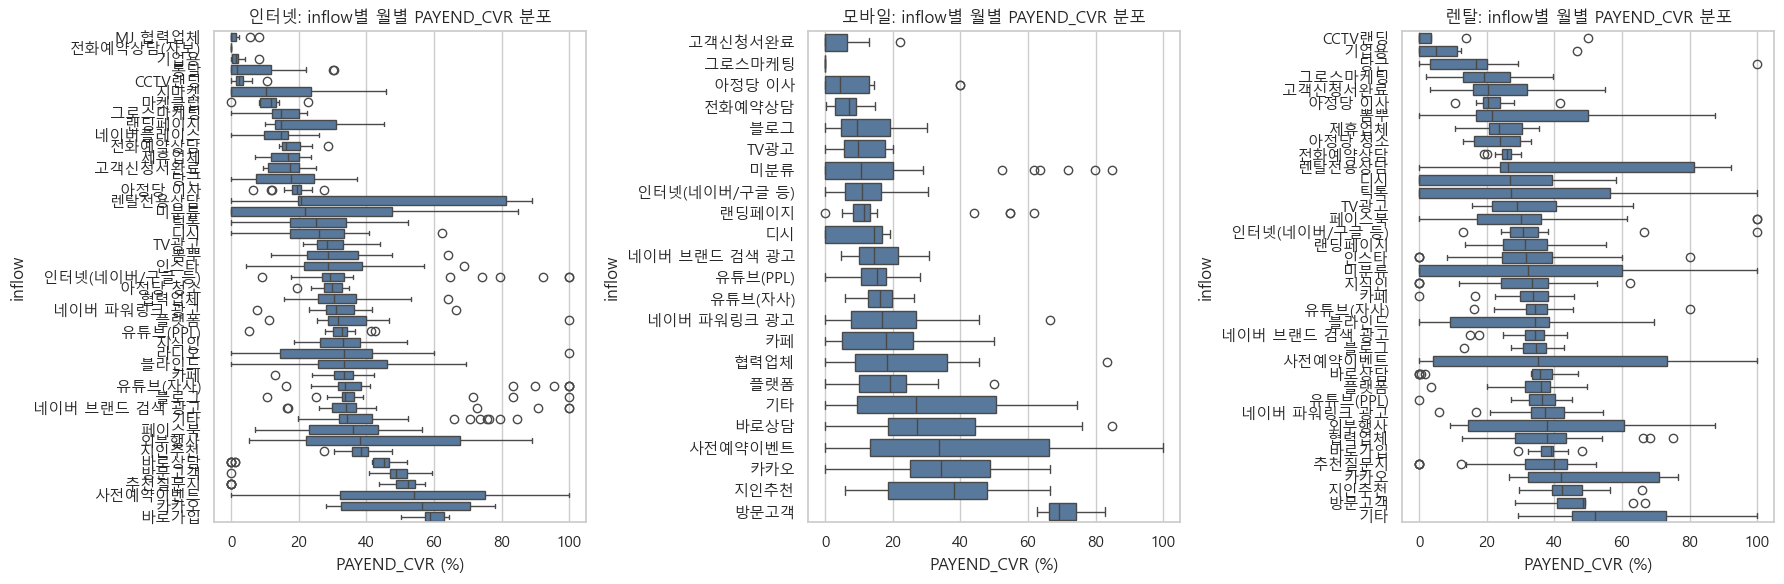

In [16]:
# 박스플롯: 상품별 inflow의 월별 PAYEND_CVR 분포
_focus = ["인터넷", "모바일", "렌탈"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, prod in zip(axes, _focus):
    sub = step32_monthly_f[step32_monthly_f["MAIN_CATEGORY_NAME"] == prod].copy()
    # inflow는 이 상품 내부 중앙값 기준 정렬
    _order = (
        sub.groupby("INFLOW_PATH_NAME")["payend_cvr"].median().sort_values().index.tolist()
    )
    sns.boxplot(
        data=sub,
        x="payend_cvr",
        y="INFLOW_PATH_NAME",
        order=_order,
        color="#4C78A8",
        ax=ax,
    )
    ax.set_title(f"{prod}: inflow별 월별 PAYEND_CVR 분포")
    ax.set_xlabel("PAYEND_CVR (%)")
    ax.set_ylabel("inflow")
plt.tight_layout()
plt.show()


#### Step 3-3 해석 가이드

- 본 검증은 기존 Step 3~4의 "성과 효율 차이" 해석을 **숫자 근거로 뒷받침**하기 위한 보완 단계다. 기존 결론을 낮추거나 뒤집는 것이 아니다.
- 실측치: 상품 내부에서 inflow 간 월별 `PAYEND_CVR` 중앙값들의 IQR은 **인터넷 17.6%p / 모바일 12.7%p / 렌탈 10.9%p** 로 좁지 않았다.
- 결과적으로 후단 운영이 inflow별로 **균질하지 않다**는 점이 확인된다. 따라서 `PAYEND_CVR` 비교는 "앞단 유입 품질"만이 아니라 **"앞단 유입 품질 + 계약 이후 운영 품질"이 결합된 결과**로 읽는 것이 안전하며, 이 결론은 기존 Step 3-1에서 "inflow별 `TOTAL_COUNT`, `CONSULT_REQUEST_COUNT`는 직접 관측되지 않는다"는 선언과 일관된다.
- 이 해석은 Step 6~7의 믹스 조정 추정치가 "옮긴 물량에서도 관측 CVR이 그대로 실현된다"는 강한 전제를 깔지 않도록 제약을 건다. 실제 실행 시에는 후단 프로세스(계약 후 개통/지급 단계) 점검을 병행 액션으로 두어야 한다.


## 4. 성과 효율 비교

이 단계에서는 실제로 `상품 × inflow` 단위 성과를 비교한다.  
여기서 보고 싶은 것은 같은 상품 안에서도 inflow에 따라 계약 물량, 지급전환율, 계약당 매출, 매출 기여도가 어떻게 달라지는지이다.

비교 범위는 아래처럼 둔다.

- 사용 데이터: `4번.csv`
- 분석 단위: `MAIN_CATEGORY_NAME × INFLOW_PATH_NAME`
- 제외: `재인입`
- 시각화 범위: 전체 계약 물량 기준 상위 inflow 중심

즉, 이 단계는 `상품별 inflow 성과가 실제로 다르다`는 점을 보여주는 단계이며,  
아직 이 단계에서 과대배분 / 과소배분 결론을 내리지는 않는다.

In [17]:
df4_step4 = df4.copy()
df4_step4["INFLOW_PATH_NAME"] = df4_step4["INFLOW_PATH_NAME"].fillna("미분류")
df4_step4 = df4_step4[df4_step4["INFLOW_PATH_NAME"] != "재인입"].copy()

product_inflow_performance = (
    df4_step4.groupby(["MAIN_CATEGORY_NAME", "INFLOW_PATH_NAME"], as_index=False)
    .agg(
        contract_count=("CONTRACT_COUNT", "sum"),
        payend_count=("PAYEND_COUNT", "sum"),
        total_net_sales=("TOTAL_NET_SALES", "sum"),
    )
)

product_inflow_performance["payend_cvr"] = np.where(
    product_inflow_performance["contract_count"] > 0,
    product_inflow_performance["payend_count"] / product_inflow_performance["contract_count"] * 100,
    np.nan,
)
product_inflow_performance["net_sales_per_contract"] = np.where(
    product_inflow_performance["contract_count"] > 0,
    product_inflow_performance["total_net_sales"] / product_inflow_performance["contract_count"],
    np.nan,
)
product_inflow_performance["contract_share"] = (
    product_inflow_performance.groupby("MAIN_CATEGORY_NAME")["contract_count"]
    .transform(lambda s: s / s.sum() * 100)
)
product_inflow_performance["sales_contribution"] = (
    product_inflow_performance.groupby("MAIN_CATEGORY_NAME")["total_net_sales"]
    .transform(lambda s: s / s.sum() * 100)
)

major_inflows = (
    product_inflow_performance.groupby("INFLOW_PATH_NAME")["contract_count"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .index
)

product_order = step2_summary["MAIN_CATEGORY_NAME"].tolist()
step4_plot_df = product_inflow_performance[
    product_inflow_performance["INFLOW_PATH_NAME"].isin(major_inflows)
].copy()

step4_plot_df = step4_plot_df.assign(
    MAIN_CATEGORY_NAME=pd.Categorical(step4_plot_df["MAIN_CATEGORY_NAME"], categories=product_order, ordered=True)
).sort_values(["MAIN_CATEGORY_NAME", "contract_count"], ascending=[True, False])

product_inflow_performance.sort_values(["MAIN_CATEGORY_NAME", "contract_count"], ascending=[True, False]).head(20)

,MAIN_CATEGORY_NAME,INFLOW_PATH_NAME,contract_count,payend_count,total_net_sales,payend_cvr,net_sales_per_contract,contract_share,sales_contribution
27,기업용인터넷,플랫폼,2725,5,1446500,0.183486,530.825688,17.790690,8.870653
17,기업용인터넷,인터넷(네이버/구글 등),2337,12,2733500,0.513479,1169.661960,15.257557,16.763173
23,기업용인터넷,카카오,2321,2,0,0.086170,0.000000,15.153098,0.000000
18,기업용인터넷,전화예약상담,2202,6,1704248,0.272480,773.954587,14.376183,10.451291
16,기업용인터넷,유튜브(자사),1178,7,3032142,0.594228,2573.974533,7.690801,18.594593
7,기업용인터넷,랜딩페이지,914,3,661300,0.328228,723.522976,5.967226,4.055418
12,기업용인터넷,블로그,732,4,2425499,0.546448,3313.523224,4.779004,14.874358
4,기업용인터넷,네이버 브랜드 검색 광고,721,7,1524890,0.970874,2114.965326,4.707188,9.351379
2,기업용인터넷,기업용,504,1,0,0.198413,0.000000,3.290462,0.000000
0,기업용인터넷,CCTV랜딩,450,1,320000,0.222222,711.111111,2.937912,1.962398


In [18]:
step4_display = step4_plot_df[[
    "MAIN_CATEGORY_NAME",
    "INFLOW_PATH_NAME",
    "contract_count",
    "contract_share",
    "payend_cvr",
    "net_sales_per_contract",
    "sales_contribution",
    "total_net_sales",
]].copy()

display(
    step4_display.style.format(
        {
            "contract_count": "{:,.0f}",
            "contract_share": "{:,.2f}",
            "payend_cvr": "{:,.2f}",
            "net_sales_per_contract": "{:,.0f}",
            "sales_contribution": "{:,.2f}",
            "total_net_sales": "{:,.0f}",
        }
    )
)

,MAIN_CATEGORY_NAME,INFLOW_PATH_NAME,contract_count,contract_share,payend_cvr,net_sales_per_contract,sales_contribution,total_net_sales
227,인터넷,전화예약상담,"939,791",24.41,17.16,"68,510",13.70,"64,385,057,763"
208,인터넷,미분류,"634,027",16.47,28.14,"121,828",16.43,"77,242,013,801"
226,인터넷,인터넷(네이버/구글 등),"300,627",7.81,29.84,"112,383",7.19,"33,785,492,998"
223,인터넷,유튜브(자사),"295,731",7.68,32.55,"147,784",9.30,"43,704,403,533"
234,인터넷,카카오,"286,309",7.44,44.06,"171,258",10.43,"49,032,667,102"
213,인터넷,블로그,"162,791",4.23,33.15,"141,773",4.91,"23,079,406,963"
204,인터넷,랜딩페이지,"140,744",3.66,14.38,"73,274",2.19,"10,312,873,745"
210,인터넷,바로상담,"136,454",3.54,45.93,"189,580",5.50,"25,869,007,961"
66,렌탈,전화예약상담,"172,727",19.50,24.91,"89,005",14.35,"15,373,559,561"
49,렌탈,미분류,"119,076",13.44,42.42,"139,460",15.50,"16,606,372,452"


아래 시각화는 전체 계약 물량 기준 상위 inflow를 중심으로, 상품별 inflow 성과가 어떻게 달라지는지 비교하기 위한 것이다.  
색이 진할수록 해당 지표 값이 높다는 의미이며, `계약 물량 비중`과 `매출 기여도`는 상품 내부 비중으로 해석한다.

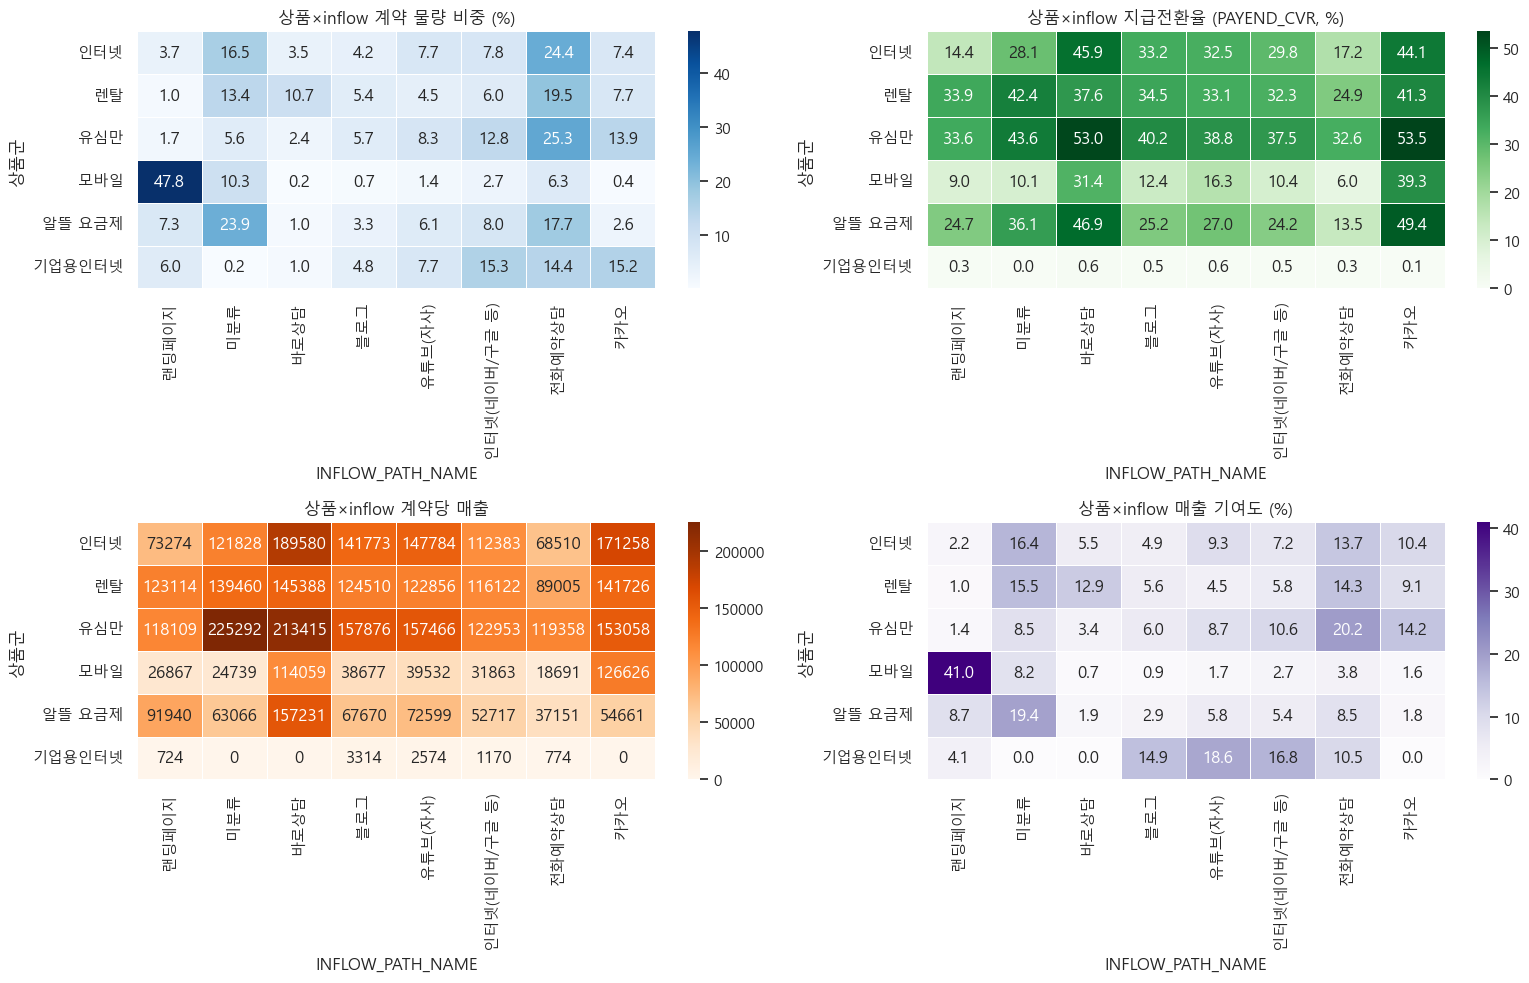

In [19]:
contract_share_pivot = step4_plot_df.pivot(index="MAIN_CATEGORY_NAME", columns="INFLOW_PATH_NAME", values="contract_share").reindex(product_order)
payend_cvr_pivot = step4_plot_df.pivot(index="MAIN_CATEGORY_NAME", columns="INFLOW_PATH_NAME", values="payend_cvr").reindex(product_order)
nspc_pivot = step4_plot_df.pivot(index="MAIN_CATEGORY_NAME", columns="INFLOW_PATH_NAME", values="net_sales_per_contract").reindex(product_order)
sales_contribution_pivot = step4_plot_df.pivot(index="MAIN_CATEGORY_NAME", columns="INFLOW_PATH_NAME", values="sales_contribution").reindex(product_order)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.heatmap(contract_share_pivot, cmap="Blues", annot=True, fmt=".1f", linewidths=0.5, ax=axes[0, 0])
axes[0, 0].set_title("상품×inflow 계약 물량 비중 (%)")
axes[0, 0].set_xlabel("INFLOW_PATH_NAME")
axes[0, 0].set_ylabel("상품군")

sns.heatmap(payend_cvr_pivot, cmap="Greens", annot=True, fmt=".1f", linewidths=0.5, ax=axes[0, 1])
axes[0, 1].set_title("상품×inflow 지급전환율 (PAYEND_CVR, %)")
axes[0, 1].set_xlabel("INFLOW_PATH_NAME")
axes[0, 1].set_ylabel("상품군")

sns.heatmap(nspc_pivot, cmap="Oranges", annot=True, fmt=".0f", linewidths=0.5, ax=axes[1, 0])
axes[1, 0].set_title("상품×inflow 계약당 매출")
axes[1, 0].set_xlabel("INFLOW_PATH_NAME")
axes[1, 0].set_ylabel("상품군")

sns.heatmap(sales_contribution_pivot, cmap="Purples", annot=True, fmt=".1f", linewidths=0.5, ax=axes[1, 1])
axes[1, 1].set_title("상품×inflow 매출 기여도 (%)")
axes[1, 1].set_xlabel("INFLOW_PATH_NAME")
axes[1, 1].set_ylabel("상품군")

plt.tight_layout()
plt.show()

In [20]:
step4_top_summary = (
    step4_plot_df.groupby("MAIN_CATEGORY_NAME")
    .apply(
        lambda g: pd.Series(
            {
                "largest_inflow": g.loc[g["contract_share"].idxmax(), "INFLOW_PATH_NAME"],
                "largest_inflow_share": g["contract_share"].max(),
                "best_payend_cvr_inflow": g.loc[g["payend_cvr"].idxmax(), "INFLOW_PATH_NAME"],
                "best_payend_cvr": g["payend_cvr"].max(),
                "best_nspc_inflow": g.loc[g["net_sales_per_contract"].idxmax(), "INFLOW_PATH_NAME"],
                "best_nspc": g["net_sales_per_contract"].max(),
            }
        )
    )
    .reset_index()
)

display(
    step4_top_summary.style.format(
        {
            "largest_inflow_share": "{:,.1f}%",
            "best_payend_cvr": "{:,.1f}%",
            "best_nspc": "{:,.0f}",
        }
    )
)

C:\Users\rhals\AppData\Local\Temp\ipykernel_25248\49294242.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  step4_plot_df.groupby("MAIN_CATEGORY_NAME")
C:\Users\rhals\AppData\Local\Temp\ipykernel_25248\49294242.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,MAIN_CATEGORY_NAME,largest_inflow,largest_inflow_share,best_payend_cvr_inflow,best_payend_cvr,best_nspc_inflow,best_nspc
0,인터넷,전화예약상담,24.4%,바로상담,45.9%,바로상담,"189,580"
1,렌탈,전화예약상담,19.5%,미분류,42.4%,바로상담,"145,388"
2,유심만,전화예약상담,25.3%,카카오,53.5%,미분류,"225,292"
3,모바일,랜딩페이지,47.8%,카카오,39.3%,카카오,"126,626"
4,알뜰 요금제,미분류,23.9%,카카오,49.4%,바로상담,"157,231"
5,기업용인터넷,인터넷(네이버/구글 등),15.3%,바로상담,0.6%,블로그,"3,314"


### Step 4 해석 가이드

이 단계에서 확인하고 싶은 것은 같은 상품 안에서도 inflow에 따라 성과 효율 차이가 실제로 존재하는지이다.

1. 상품별로 현재 많이 사용되는 inflow는 서로 다르며, 계약 물량 비중도 동일하지 않다.
2. 같은 상품 안에서도 inflow별 지급전환율은 차이가 날 수 있다.
3. 계약당 매출과 매출 기여도 역시 inflow에 따라 달라질 수 있으며, 전환이 높은 inflow가 항상 가장 큰 매출 기여를 만드는 것은 아닐 수 있다.
4. 즉, 상품별 inflow 성과 효율은 동일하지 않으며, 상품 내부에서도 어떤 inflow가 더 강한지 약한지가 구분될 수 있다.
5. 따라서 바로 다음 소단계에서는 이 차이가 우연한 수준인지 통계적으로 점검하고, 이후 Step5에서 현재 운영 물량 비중과 실제 성과 효율이 얼마나 정렬되어 있는지 확인할 필요가 있다.

이 단계의 결론은 `상품×inflow별 성과 효율 차이가 존재한다`는 것이다.  
아래에서는 시각적으로 보인 차이를 통계적으로 점검한 뒤, Step5에서 운영 물량 비중과 효율의 미스매치를 확인한다.

### 4-1. 지급전환율 차이의 통계적 검증

Heatmap에서 본 지급전환율 차이가 실제로도 의미 있는지 확인하기 위해, 상품 내부 inflow 간 `payend / not_payend` 분포가 동일한지 검정한다.

- 검정 대상: 상품별 주요 inflow (`contract_count >= 100`)
- 검정 방법: 카이제곱 검정 (`chi-square test of independence`)
- 해석 기준: `p < 0.05`이면 상품 내부에서 inflow별 지급전환율 차이가 존재한다고 본다.
- 효과크기: `Cramer's V`를 함께 보고, 값이 클수록 inflow에 따라 전환 편차가 더 뚜렷하다고 해석한다.

In [21]:
step4_stat_base = (
    df4_step4.groupby(["MAIN_CATEGORY_NAME", "INFLOW_PATH_NAME"], as_index=False)
    .agg(
        contract_count=("CONTRACT_COUNT", "sum"),
        payend_count=("PAYEND_COUNT", "sum"),
    )
)

step4_stat_base = step4_stat_base[step4_stat_base["contract_count"] >= 100].copy()
step4_stat_base["non_payend_count"] = step4_stat_base["contract_count"] - step4_stat_base["payend_count"]
step4_stat_base["payend_cvr"] = np.where(
    step4_stat_base["contract_count"] > 0,
    step4_stat_base["payend_count"] / step4_stat_base["contract_count"] * 100,
    np.nan,
)

chi2_results = []
pairwise_cvr_results = []
z_975 = 1.959963984540054

for product, g in step4_stat_base.groupby("MAIN_CATEGORY_NAME"):
    g = g.sort_values("contract_count", ascending=False).copy()
    if len(g) < 2:
        continue

    contingency = np.vstack([
        g["payend_count"].to_numpy(),
        g["non_payend_count"].to_numpy(),
    ])
    top_inflow_row = g.iloc[0]
    best_payend_row = g.sort_values(["payend_cvr", "contract_count"], ascending=[False, False]).iloc[0]

    if g["payend_count"].sum() == 0 or g["non_payend_count"].sum() == 0:
        chi2 = np.nan
        p_value = np.nan
        cramers_v = np.nan
        significance = "검정 불가"
    else:
        chi2, p_value, dof, expected = chi2_contingency(contingency)
        n_obs = contingency.sum()
        cramers_v = np.sqrt(chi2 / (n_obs * (min(contingency.shape) - 1))) if n_obs > 0 else np.nan
        significance = "유의" if p_value < 0.05 else "비유의"

    chi2_results.append(
        {
            "MAIN_CATEGORY_NAME": product,
            "inflow_count_tested": len(g),
            "tested_contracts": g["contract_count"].sum(),
            "chi2_stat": chi2,
            "p_value": p_value,
            "cramers_v": cramers_v,
            "largest_inflow": top_inflow_row["INFLOW_PATH_NAME"],
            "best_payend_inflow": best_payend_row["INFLOW_PATH_NAME"],
            "largest_inflow_cvr": top_inflow_row["payend_cvr"],
            "best_payend_cvr": best_payend_row["payend_cvr"],
            "significance": significance,
        }
    )

    if (
        top_inflow_row["INFLOW_PATH_NAME"] != best_payend_row["INFLOW_PATH_NAME"]
        and g["payend_count"].sum() > 0
        and g["non_payend_count"].sum() > 0
    ):
        p_top = top_inflow_row["payend_count"] / top_inflow_row["contract_count"]
        p_best = best_payend_row["payend_count"] / best_payend_row["contract_count"]
        diff_pct = (p_best - p_top) * 100
        se_pct = np.sqrt(
            p_top * (1 - p_top) / top_inflow_row["contract_count"]
            + p_best * (1 - p_best) / best_payend_row["contract_count"]
        ) * 100

        pairwise_cvr_results.append(
            {
                "MAIN_CATEGORY_NAME": product,
                "largest_inflow": top_inflow_row["INFLOW_PATH_NAME"],
                "best_payend_inflow": best_payend_row["INFLOW_PATH_NAME"],
                "largest_inflow_cvr": top_inflow_row["payend_cvr"],
                "best_payend_cvr": best_payend_row["payend_cvr"],
                "payend_cvr_diff_pctp": diff_pct,
                "ci_low": diff_pct - z_975 * se_pct,
                "ci_high": diff_pct + z_975 * se_pct,
            }
        )

chi2_summary = pd.DataFrame(chi2_results).sort_values(["p_value", "cramers_v"])
pairwise_cvr_summary = pd.DataFrame(pairwise_cvr_results).sort_values("payend_cvr_diff_pctp", ascending=False)

display(
    chi2_summary.style.format(
        {
            "tested_contracts": "{:,.0f}",
            "chi2_stat": "{:,.2f}",
            "p_value": "{:,.4f}",
            "cramers_v": "{:,.3f}",
            "largest_inflow_cvr": "{:,.1f}%",
            "best_payend_cvr": "{:,.1f}%",
        }
    )
)

display(
    pairwise_cvr_summary.style.format(
        {
            "largest_inflow_cvr": "{:,.1f}%",
            "best_payend_cvr": "{:,.1f}%",
            "payend_cvr_diff_pctp": "{:+,.1f}%p",
            "ci_low": "{:+,.1f}%p",
            "ci_high": "{:+,.1f}%p",
        }
    )
)

chi2_summary

,MAIN_CATEGORY_NAME,inflow_count_tested,tested_contracts,chi2_stat,p_value,cramers_v,largest_inflow,best_payend_inflow,largest_inflow_cvr,best_payend_cvr,significance
1,렌탈,39,"885,661","20,338.43",0.0000,0.152,전화예약상담,기타,24.9%,52.2%,유의
4,유심만,28,"172,314","5,490.47",0.0000,0.179,전화예약상담,바로가입,32.6%,69.9%,유의
5,인터넷,48,"3,849,309","240,787.06",0.0000,0.250,전화예약상담,숨고,17.2%,65.0%,유의
3,알뜰 요금제,21,"41,644","3,088.81",0.0000,0.272,미분류,바로가입,36.1%,75.9%,유의
2,모바일,25,"365,116","30,693.28",0.0000,0.290,랜딩페이지,방문고객,9.0%,68.8%,유의
0,기업용인터넷,17,"15,050",24.99,0.0701,0.041,플랫폼,네이버 브랜드 검색 광고,0.2%,1.0%,비유의


,MAIN_CATEGORY_NAME,largest_inflow,best_payend_inflow,largest_inflow_cvr,best_payend_cvr,payend_cvr_diff_pctp,ci_low,ci_high
2,모바일,랜딩페이지,방문고객,9.0%,68.8%,+59.8%p,+58.7%p,+60.8%p
5,인터넷,전화예약상담,숨고,17.2%,65.0%,+47.8%p,+42.2%p,+53.5%p
3,알뜰 요금제,미분류,바로가입,36.1%,75.9%,+39.8%p,+33.6%p,+46.0%p
4,유심만,전화예약상담,바로가입,32.6%,69.9%,+37.3%p,+35.8%p,+38.8%p
1,렌탈,전화예약상담,기타,24.9%,52.2%,+27.3%p,+26.2%p,+28.4%p
0,기업용인터넷,플랫폼,네이버 브랜드 검색 광고,0.2%,1.0%,+0.8%p,+0.1%p,+1.5%p


,MAIN_CATEGORY_NAME,inflow_count_tested,tested_contracts,chi2_stat,p_value,cramers_v,largest_inflow,best_payend_inflow,largest_inflow_cvr,best_payend_cvr,significance
1,렌탈,39,885661,20338.428176,0.000000,0.151539,전화예약상담,기타,24.906934,52.230323,유의
4,유심만,28,172314,5490.471128,0.000000,0.178503,전화예약상담,바로가입,32.623367,69.896907,유의
5,인터넷,48,3849309,240787.057522,0.000000,0.250107,전화예약상담,숨고,17.162646,64.963504,유의
3,알뜰 요금제,21,41644,3088.809888,0.000000,0.272345,미분류,바로가입,36.138069,75.935829,유의
2,모바일,25,365116,30693.282392,0.000000,0.289939,랜딩페이지,방문고객,9.009380,68.776539,유의
0,기업용인터넷,17,15050,24.986753,0.070059,0.040746,플랫폼,네이버 브랜드 검색 광고,0.183486,0.970874,비유의


### 4-2. 계약당 매출의 월별 불확실성 점검

계약당 매출은 개별 계약 단위가 아니라 월 집계 데이터만 있으므로, 여기서는 월을 재표본화하는 방식으로 불확실성을 본다.

- 비교 대상: 상품별 최대 물량 inflow와 최고 계약당 매출 inflow
- 추정 방식: 월 단위 부트스트랩 (`sum(total_net_sales) / sum(contract_count)`)
- 해석 기준: 신뢰구간이 좁을수록 월별 변동성을 감안해도 계약당 매출 수준이 비교적 안정적이라고 본다.

In [22]:
monthly_sales_base = (
    df4_step4.groupby(["YEAR_MONTH", "MAIN_CATEGORY_NAME", "INFLOW_PATH_NAME"], as_index=False)
    .agg(
        contract_count=("CONTRACT_COUNT", "sum"),
        total_net_sales=("TOTAL_NET_SALES", "sum"),
    )
)
monthly_sales_base = monthly_sales_base[monthly_sales_base["contract_count"] > 0].copy()

nspc_base = (
    monthly_sales_base.groupby(["MAIN_CATEGORY_NAME", "INFLOW_PATH_NAME"], as_index=False)
    .agg(
        total_contract_count=("contract_count", "sum"),
        total_net_sales=("total_net_sales", "sum"),
        unique_months=("YEAR_MONTH", "nunique"),
    )
)
nspc_base = nspc_base[(nspc_base["total_contract_count"] >= 100) & (nspc_base["unique_months"] >= 3)].copy()
nspc_base["net_sales_per_contract"] = np.where(
    nspc_base["total_contract_count"] > 0,
    nspc_base["total_net_sales"] / nspc_base["total_contract_count"],
    np.nan,
)

def bootstrap_weighted_nspc_ci(sub_df, n_boot=2000, seed=42):
    point = sub_df["total_net_sales"].sum() / sub_df["contract_count"].sum()
    if len(sub_df) == 1:
        return point, point, point

    rng = np.random.default_rng(seed)
    boot_values = []
    indices = np.arange(len(sub_df))

    for _ in range(n_boot):
        sampled_idx = rng.choice(indices, size=len(sub_df), replace=True)
        sampled = sub_df.iloc[sampled_idx]
        sampled_contracts = sampled["contract_count"].sum()
        sampled_sales = sampled["total_net_sales"].sum()
        boot_values.append(sampled_sales / sampled_contracts if sampled_contracts > 0 else np.nan)

    return point, np.nanpercentile(boot_values, 2.5), np.nanpercentile(boot_values, 97.5)

bootstrap_rows = []
for product, g in nspc_base.groupby("MAIN_CATEGORY_NAME"):
    g = g.sort_values("total_contract_count", ascending=False).copy()
    largest_row = g.iloc[0]
    best_nspc_row = g.sort_values(["net_sales_per_contract", "total_contract_count"], ascending=[False, False]).iloc[0]

    selected = {}
    selected[largest_row["INFLOW_PATH_NAME"]] = "최대 물량 inflow"
    if best_nspc_row["INFLOW_PATH_NAME"] in selected:
        selected[best_nspc_row["INFLOW_PATH_NAME"]] += " / 최고 계약당 매출 inflow"
    else:
        selected[best_nspc_row["INFLOW_PATH_NAME"]] = "최고 계약당 매출 inflow"

    for inflow_name, role in selected.items():
        sub_df = monthly_sales_base[
            (monthly_sales_base["MAIN_CATEGORY_NAME"] == product)
            & (monthly_sales_base["INFLOW_PATH_NAME"] == inflow_name)
        ].copy()
        point, ci_low, ci_high = bootstrap_weighted_nspc_ci(sub_df)
        bootstrap_rows.append(
            {
                "MAIN_CATEGORY_NAME": product,
                "INFLOW_PATH_NAME": inflow_name,
                "role": role,
                "total_contract_count": sub_df["contract_count"].sum(),
                "unique_months": sub_df["YEAR_MONTH"].nunique(),
                "net_sales_per_contract": point,
                "ci_low": ci_low,
                "ci_high": ci_high,
            }
        )

nspc_bootstrap_summary = pd.DataFrame(bootstrap_rows).sort_values(["MAIN_CATEGORY_NAME", "role"])

display(
    nspc_bootstrap_summary.style.format(
        {
            "total_contract_count": "{:,.0f}",
            "net_sales_per_contract": "{:,.0f}",
            "ci_low": "{:,.0f}",
            "ci_high": "{:,.0f}",
        }
    )
)

nspc_bootstrap_summary

,MAIN_CATEGORY_NAME,INFLOW_PATH_NAME,role,total_contract_count,unique_months,net_sales_per_contract,ci_low,ci_high
1,기업용인터넷,블로그,최고 계약당 매출 inflow,732,16,"3,314",0,"8,863"
0,기업용인터넷,플랫폼,최대 물량 inflow,"2,725",10,531,0,"1,395"
3,렌탈,기타,최고 계약당 매출 inflow,"8,093",33,"189,194","166,871","209,872"
2,렌탈,전화예약상담,최대 물량 inflow,"172,727",22,"89,005","75,654","102,415"
5,모바일,카카오,최고 계약당 매출 inflow,"1,436",22,"126,626","97,266","155,822"
4,모바일,랜딩페이지,최대 물량 inflow,"174,729",23,"26,867","20,514","33,486"
7,알뜰 요금제,특가딜,최고 계약당 매출 inflow,"1,892",5,"292,047","145,589","755,841"
6,알뜰 요금제,미분류,최대 물량 inflow,"9,995",33,"63,066","52,081","70,944"
9,유심만,바로가입,최고 계약당 매출 inflow,"3,880",21,"266,896","211,326","323,288"
8,유심만,전화예약상담,최대 물량 inflow,"43,711",22,"119,358","95,592","145,025"


,MAIN_CATEGORY_NAME,INFLOW_PATH_NAME,role,total_contract_count,unique_months,net_sales_per_contract,ci_low,ci_high
1,기업용인터넷,블로그,최고 계약당 매출 inflow,732,16,3313.523224,0.000000,8862.817727
0,기업용인터넷,플랫폼,최대 물량 inflow,2725,10,530.825688,0.000000,1395.139403
3,렌탈,기타,최고 계약당 매출 inflow,8093,33,189193.662424,166870.788730,209872.057999
2,렌탈,전화예약상담,최대 물량 inflow,172727,22,89004.959045,75654.021206,102414.577778
5,모바일,카카오,최고 계약당 매출 inflow,1436,22,126626.010446,97265.633847,155822.346851
4,모바일,랜딩페이지,최대 물량 inflow,174729,23,26866.680219,20514.292293,33485.841071
7,알뜰 요금제,특가딜,최고 계약당 매출 inflow,1892,5,292046.617336,145589.211823,755840.559441
6,알뜰 요금제,미분류,최대 물량 inflow,9995,33,63066.396698,52081.450800,70943.593451
9,유심만,바로가입,최고 계약당 매출 inflow,3880,21,266895.591753,211326.478208,323287.934754
8,유심만,전화예약상담,최대 물량 inflow,43711,22,119358.143145,95591.756270,145025.378303


### Step 4 통계 검증 해석 가이드

이 소단계의 목적은 Step4에서 시각적으로 보인 차이가 단순 노이즈인지, 아니면 실제로도 확인되는 차이인지를 보강하는 것이다.

1. 카이제곱 검정에서 `p_value < 0.05`이면, 해당 상품 내부에서는 inflow에 따라 지급전환율 차이가 존재한다고 해석할 수 있다.
2. `Cramer's V`는 그 차이의 상대적 크기를 보조적으로 보여주며, 값이 클수록 inflow별 전환 편차가 더 뚜렷하다는 뜻이다.
3. 최대 물량 inflow와 최고 지급전환율 inflow가 다르고, 그 차이의 신뢰구간이 0을 넘어서면 시각적으로 보인 전환 격차가 우연으로만 보기 어렵다는 근거가 된다.
4. 계약당 매출은 월 단위 부트스트랩 신뢰구간으로 보며, 신뢰구간 폭이 좁을수록 해당 inflow의 수익성이 월별 변동에도 비교적 안정적이라고 볼 수 있다.
5. 따라서 Step4의 차이는 단순한 시각적 인상에 그치지 않고, 주요 상품에서는 통계적으로도 점검 가능한 차이로 이어질 수 있다.

이 소단계의 결론은 `주요 상품에서 inflow별 성과 차이는 통계적으로도 점검 가능한 수준으로 관측된다`는 것이다.  
다음 Step5에서는 이 차이가 현재 inflow 운영 비중과 얼마나 정렬되어 있는지 본다.

## 5. 주력 inflow 효율 갭 확인

Step4에서는 상품별로 inflow 성과 차이가 실제로 존재하는지를 확인했다.  
이번 Step5에서는 **매출 영향이 큰 상품 중에서, 현재 주력으로 쓰이는 inflow가 기대 성과 대비 얼마나 뒤처지는지**를 점검한다.

즉, 이 단계의 목적은 다음과 같다.

1. 어떤 상품을 우선 점검해야 하는지 선정한다
2. 그 상품에서 현재 가장 많이 쓰는 inflow가 무엇인지 확인한다
3. 그 주력 inflow의 효율 격차가 어느 정도인지 수치로 보여준다

### 5-1. Step5 분석 대상 선정 기준

Step5는 모든 상품을 다시 보는 단계가 아니라, **우선 점검 가치가 높은 상품을 좁혀 보는 단계**다.

- 매출 기준: 총 순매출 상위 4개 상품
- 효율 기준: 상위 4개 안에서 `overall_cvr_wavg` 또는 `sales_per_volume`이 중앙값 이하
- 검증 기준: Step4 통계 검증에서 `significance = 유의`
- 구조 기준: 최대 물량 inflow와 최고 지급전환율 inflow가 서로 다름

즉, 이 조건을 만족하는 상품만 Step5의 우선 점검 대상으로 본다.

In [23]:
step5_product_base = (
    step2_summary[step2_summary["total_net_sales"] > 0]
    .merge(
        chi2_summary[[
            "MAIN_CATEGORY_NAME",
            "significance",
            "largest_inflow",
            "best_payend_inflow",
            "largest_inflow_cvr",
            "best_payend_cvr",
        ]],
        on="MAIN_CATEGORY_NAME",
        how="left",
    )
    .copy()
)

top_revenue_n = min(4, len(step5_product_base))
step5_priority_pool = step5_product_base.nlargest(top_revenue_n, "total_net_sales").copy()

pool_cvr_median = step5_priority_pool["overall_cvr_wavg"].median()
pool_spv_median = step5_priority_pool["sales_per_volume"].median()

step5_priority_pool["low_conversion_efficiency"] = step5_priority_pool["overall_cvr_wavg"] <= pool_cvr_median
step5_priority_pool["low_revenue_efficiency"] = step5_priority_pool["sales_per_volume"] <= pool_spv_median
step5_priority_pool["statistically_supported"] = step5_priority_pool["significance"].eq("유의")
step5_priority_pool["largest_vs_best_different"] = (
    step5_priority_pool["largest_inflow"] != step5_priority_pool["best_payend_inflow"]
)
step5_priority_pool["step5_target"] = (
    step5_priority_pool["statistically_supported"]
    & step5_priority_pool["largest_vs_best_different"]
    & (
        step5_priority_pool["low_conversion_efficiency"]
        | step5_priority_pool["low_revenue_efficiency"]
    )
)

step5_priority_pool["selection_reason"] = np.select(
    [
        step5_priority_pool["low_conversion_efficiency"] & step5_priority_pool["low_revenue_efficiency"],
        step5_priority_pool["low_conversion_efficiency"],
        step5_priority_pool["low_revenue_efficiency"],
    ],
    [
        "전환 효율과 수익 효율 모두 낮음",
        "전환 효율이 상대적으로 낮음",
        "수익 효율이 상대적으로 낮음",
    ],
    default="-"
)

step5_target_products = step5_priority_pool.loc[step5_priority_pool["step5_target"], "MAIN_CATEGORY_NAME"].tolist()

display(
    step5_priority_pool[[
        "MAIN_CATEGORY_NAME",
        "total_net_sales",
        "overall_cvr_wavg",
        "sales_per_volume",
        "significance",
        "largest_inflow",
        "best_payend_inflow",
        "selection_reason",
        "step5_target",
    ]].style.format(
        {
            "total_net_sales": "{:,.0f}",
            "overall_cvr_wavg": "{:,.2f}%",
            "sales_per_volume": "{:,.0f}",
        }
    )
)

step5_target_products

,MAIN_CATEGORY_NAME,total_net_sales,overall_cvr_wavg,sales_per_volume,significance,largest_inflow,best_payend_inflow,selection_reason,step5_target
0,인터넷,"587,415,696,892",31.73%,"128,050",유의,전화예약상담,숨고,전환 효율이 상대적으로 낮음,True
1,렌탈,"140,648,733,955",35.17%,"126,197",유의,전화예약상담,기타,수익 효율이 상대적으로 낮음,True
2,유심만,"51,135,661,437",51.86%,"168,225",유의,전화예약상담,바로가입,-,False
3,모바일,"14,409,945,762",15.12%,"36,267",유의,랜딩페이지,방문고객,전환 효율과 수익 효율 모두 낮음,True


['인터넷', '렌탈', '모바일']

# 매출 영향이 큰 상품만 먼저 본다

전환 효율 기준선: 33.45%
수익 효율 기준선: 127,124

- total_net_sales 기준 상위 4개 상품만 뽑았습니다.
- 인터넷: 전환율 31.73%로 중앙값보다 낮음, 유입당 순매출 128,050은 중앙값보다 약간 높음
- 렌탈: 전환율 35.17%로 중앙값보다 높음, 유입당 순매출 126,197은 중앙값보다 낮음
- 모바일 둘다 부족함
- largest_inflow 현재 가장 많은 계약 물량을 만들어내는 inflow
- best_payend_inflow : 해당 상품 안에서 payend_cvr가 가장 높은 inflow입니다. 즉, 그 inflow로 들어온 계약이 최종 지급까지 이어지는 비율이 가장 높은 inflow예요.

### 5-2. 주력 inflow 효율 갭 계산

Step5의 핵심 KPI는 **주력 inflow 효율 갭**이다.  
여기서 주력 inflow는 해당 상품 안에서 `contract_count`가 가장 큰 inflow를 뜻한다.

- 기대 전환 효율: 해당 상품에서 `contract_count >= 100`인 inflow 중 `payend_cvr` 상위 3개 평균
- 기대 수익 효율: 해당 상품에서 `contract_count >= 100`인 inflow 중 `net_sales_per_contract` 상위 3개 평균
- `전환 갭 = 기대 지급전환율 - 주력 inflow 지급전환율`
- `수익 갭 = 기대 계약당 매출 - 주력 inflow 계약당 매출`

즉, 현재 가장 많이 쓰는 inflow가 상품 내부의 상위 성과 inflow 대비 얼마나 뒤처지는지를 보는 지표다.

# 상위 3개 평균이 기대수준인 이유?
- 잘하는 inflow 몇개의 공통 수준에 가깝게 보려고 했음, 같은 상품 내부에서 실제로 관찰된 값을 사용함
- 같은 상품 내부에서 관찰된 상위 성과 benchmark

In [24]:
step5_inflow_base = product_inflow_performance[
    product_inflow_performance["MAIN_CATEGORY_NAME"].isin(step5_target_products)
].copy()
step5_inflow_base = step5_inflow_base[step5_inflow_base["contract_count"] >= 100].copy()

gap_rows = []
for product, g in step5_inflow_base.groupby("MAIN_CATEGORY_NAME"):
    g = g.sort_values("contract_count", ascending=False).copy()
    largest_row = g.iloc[0]

    payend_top = g.nlargest(min(3, len(g)), "payend_cvr")
    nspc_top = g.nlargest(min(3, len(g)), "net_sales_per_contract")

    expected_payend_cvr = payend_top["payend_cvr"].mean()
    expected_nspc = nspc_top["net_sales_per_contract"].mean()

    gap_rows.append(
        {
            "MAIN_CATEGORY_NAME": product,
            "largest_inflow": largest_row["INFLOW_PATH_NAME"],
            "largest_inflow_contract_share": largest_row["contract_share"],
            "largest_inflow_sales_contribution": largest_row["sales_contribution"],
            "largest_inflow_payend_cvr": largest_row["payend_cvr"],
            "largest_inflow_nspc": largest_row["net_sales_per_contract"],
            "expected_payend_cvr": expected_payend_cvr,
            "expected_nspc": expected_nspc,
            "conversion_gap_pctp": expected_payend_cvr - largest_row["payend_cvr"],
            "revenue_gap": expected_nspc - largest_row["net_sales_per_contract"],
            "payend_benchmark_inflows": ", ".join(payend_top["INFLOW_PATH_NAME"].tolist()),
            "nspc_benchmark_inflows": ", ".join(nspc_top["INFLOW_PATH_NAME"].tolist()),
        }
    )

step5_gap_summary = (
    pd.DataFrame(gap_rows)
    .merge(
        step5_priority_pool[[
            "MAIN_CATEGORY_NAME",
            "total_net_sales",
            "contract_count",
            "overall_cvr_wavg",
            "sales_per_volume",
            "selection_reason",
        ]],
        on="MAIN_CATEGORY_NAME",
        how="left",
    )
    .sort_values(["total_net_sales", "conversion_gap_pctp"], ascending=[False, False])
)

display(
    step5_gap_summary[[
        "MAIN_CATEGORY_NAME",
        "total_net_sales",
        "selection_reason",
        "largest_inflow",
        "largest_inflow_contract_share",
        "largest_inflow_payend_cvr",
        "expected_payend_cvr",
        "conversion_gap_pctp",
        "largest_inflow_nspc",
        "expected_nspc",
        "revenue_gap",
    ]].style.format(
        {
            "total_net_sales": "{:,.0f}",
            "largest_inflow_contract_share": "{:,.2f}%",
            "largest_inflow_payend_cvr": "{:,.2f}%",
            "expected_payend_cvr": "{:,.2f}%",
            "conversion_gap_pctp": "{:+,.2f}%p",
            "largest_inflow_nspc": "{:,.0f}",
            "expected_nspc": "{:,.0f}",
            "revenue_gap": "{:+,.0f}",
        }
    )
)

step5_gap_summary

,MAIN_CATEGORY_NAME,total_net_sales,selection_reason,largest_inflow,largest_inflow_contract_share,largest_inflow_payend_cvr,expected_payend_cvr,conversion_gap_pctp,largest_inflow_nspc,expected_nspc,revenue_gap
2,인터넷,"587,415,696,892",전환 효율이 상대적으로 낮음,전화예약상담,24.41%,17.16%,58.98%,+41.82%p,"68,510","218,104","+149,594"
0,렌탈,"140,648,733,955",수익 효율이 상대적으로 낮음,전화예약상담,19.50%,24.91%,46.14%,+21.23%p,"89,005","175,115","+86,110"
1,모바일,"14,409,945,762",전환 효율과 수익 효율 모두 낮음,랜딩페이지,47.80%,9.01%,49.72%,+40.71%p,"26,867","115,696","+88,829"


,MAIN_CATEGORY_NAME,largest_inflow,largest_inflow_contract_share,largest_inflow_sales_contribution,largest_inflow_payend_cvr,largest_inflow_nspc,expected_payend_cvr,expected_nspc,conversion_gap_pctp,revenue_gap,payend_benchmark_inflows,nspc_benchmark_inflows,total_net_sales,contract_count,overall_cvr_wavg,sales_per_volume,selection_reason
2,인터넷,전화예약상담,24.412603,13.696582,17.162646,68509.974838,58.980891,218103.933252,41.818245,149593.958414,"숨고, 바로가입, 추천질문지","바로가입, 추천질문지, 바로상담",587415696892,4584578,31.734741,128050.200461,전환 효율이 상대적으로 낮음
0,렌탈,전화예약상담,19.495389,14.345845,24.906934,89004.959045,46.138986,175115.350560,21.232052,86110.391515,"기타, 방문고객, 미분류","기타, 바로가입, 틱톡",140648733955,1112608,35.173858,126196.802347,수익 효율이 상대적으로 낮음
1,모바일,랜딩페이지,47.797364,40.965899,9.009380,26866.680219,49.716065,115695.919231,40.706685,88829.239012,"방문고객, 매장전화인입, 카카오","카카오, 바로상담, 방문고객",14409945762,396040,15.124912,36266.672444,전환 효율과 수익 효율 모두 낮음


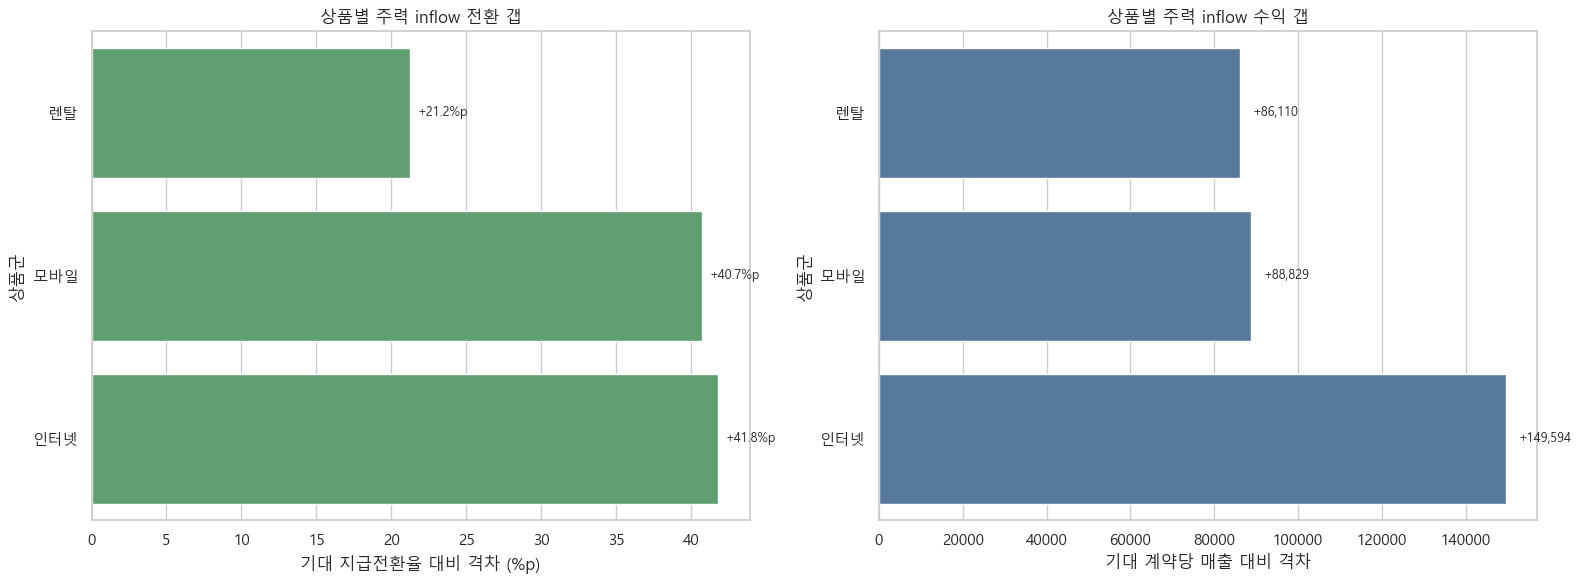

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

conversion_plot_df = step5_gap_summary.sort_values("conversion_gap_pctp", ascending=True)
revenue_plot_df = step5_gap_summary.sort_values("revenue_gap", ascending=True)

sns.barplot(
    data=conversion_plot_df,
    x="conversion_gap_pctp",
    y="MAIN_CATEGORY_NAME",
    color="#55A868",
    ax=axes[0],
)
axes[0].set_title("상품별 주력 inflow 전환 갭")
axes[0].set_xlabel("기대 지급전환율 대비 격차 (%p)")
axes[0].set_ylabel("상품군")

for i, row in conversion_plot_df.reset_index(drop=True).iterrows():
    axes[0].text(row["conversion_gap_pctp"] + 0.5, i, "{:+.1f}%p".format(row["conversion_gap_pctp"]), va="center", fontsize=9)

sns.barplot(
    data=revenue_plot_df,
    x="revenue_gap",
    y="MAIN_CATEGORY_NAME",
    color="#4C78A8",
    ax=axes[1],
)
axes[1].set_title("상품별 주력 inflow 수익 갭")
axes[1].set_xlabel("기대 계약당 매출 대비 격차")
axes[1].set_ylabel("상품군")

text_offset = max(step5_gap_summary["revenue_gap"].max() * 0.02, 1000)
for i, row in revenue_plot_df.reset_index(drop=True).iterrows():
    axes[1].text(row["revenue_gap"] + text_offset, i, "{:+,.0f}".format(row["revenue_gap"]), va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [26]:
step5_detail_table = step5_gap_summary[[
    "MAIN_CATEGORY_NAME",
    "largest_inflow",
    "payend_benchmark_inflows",
    "nspc_benchmark_inflows",
    "largest_inflow_sales_contribution",
    "largest_inflow_payend_cvr",
    "expected_payend_cvr",
    "conversion_gap_pctp",
    "largest_inflow_nspc",
    "expected_nspc",
    "revenue_gap",
]].copy()

display(
    step5_detail_table.style.format(
        {
            "largest_inflow_sales_contribution": "{:,.2f}%",
            "largest_inflow_payend_cvr": "{:,.2f}%",
            "expected_payend_cvr": "{:,.2f}%",
            "conversion_gap_pctp": "{:+,.2f}%p",
            "largest_inflow_nspc": "{:,.0f}",
            "expected_nspc": "{:,.0f}",
            "revenue_gap": "{:+,.0f}",
        }
    )
)

step5_detail_table

,MAIN_CATEGORY_NAME,largest_inflow,payend_benchmark_inflows,nspc_benchmark_inflows,largest_inflow_sales_contribution,largest_inflow_payend_cvr,expected_payend_cvr,conversion_gap_pctp,largest_inflow_nspc,expected_nspc,revenue_gap
2,인터넷,전화예약상담,"숨고, 바로가입, 추천질문지","바로가입, 추천질문지, 바로상담",13.70%,17.16%,58.98%,+41.82%p,"68,510","218,104","+149,594"
0,렌탈,전화예약상담,"기타, 방문고객, 미분류","기타, 바로가입, 틱톡",14.35%,24.91%,46.14%,+21.23%p,"89,005","175,115","+86,110"
1,모바일,랜딩페이지,"방문고객, 매장전화인입, 카카오","카카오, 바로상담, 방문고객",40.97%,9.01%,49.72%,+40.71%p,"26,867","115,696","+88,829"


,MAIN_CATEGORY_NAME,largest_inflow,payend_benchmark_inflows,nspc_benchmark_inflows,largest_inflow_sales_contribution,largest_inflow_payend_cvr,expected_payend_cvr,conversion_gap_pctp,largest_inflow_nspc,expected_nspc,revenue_gap
2,인터넷,전화예약상담,"숨고, 바로가입, 추천질문지","바로가입, 추천질문지, 바로상담",13.696582,17.162646,58.980891,41.818245,68509.974838,218103.933252,149593.958414
0,렌탈,전화예약상담,"기타, 방문고객, 미분류","기타, 바로가입, 틱톡",14.345845,24.906934,46.138986,21.232052,89004.959045,175115.350560,86110.391515
1,모바일,랜딩페이지,"방문고객, 매장전화인입, 카카오","카카오, 바로상담, 방문고객",40.965899,9.009380,49.716065,40.706685,26866.680219,115695.919231,88829.239012


### Step 5 해석 가이드

이 단계의 핵심은 현재 주력 inflow 자체를 비판하는 것이 아니라, **매출 영향이 큰 상품에서 주력 inflow가 기대 성과 대비 얼마나 뒤처지는지**를 확인하는 데 있다.

1. `step5_target = True`인 상품은 매출 영향이 크고, 효율 측면에서 우선 점검할 가치가 있는 상품이다.
2. `전환 갭`이 크면 현재 주력 inflow의 지급전환율이 상품 내부의 상위 inflow 대비 낮다는 뜻이다.
3. `수익 갭`이 크면 현재 주력 inflow의 계약당 매출이 상품 내부의 상위 inflow 대비 낮다는 뜻이다.
4. 전환 갭과 수익 갭이 모두 큰 상품일수록, 현재 주력 inflow 운영 방식을 먼저 재점검할 필요가 크다.
5. 이 결과만으로 inflow를 바로 줄이거나 늘린다고 결론내리기보다, 이후 심화분석 단계에서 해당 inflow의 구조와 개선 가능성을 함께 검토해야 한다.

Step5 결과, 인터넷·모바일·렌탈은 현재 주력 inflow가 상품 내부 상위 성과 inflow 대비 전환 및 수익 측면에서 상대적으로 뒤처지는 것으로 나타났다. 특히 인터넷은 전환 격차와 수익 격차가 모두 크게 나타나 우선 점검 필요성이 가장 높았고, 모바일은 주력 inflow의 비중이 매우 큰 반면 성과는 낮아 구조 점검 필요성이 컸다. 렌탈 역시 격차가 확인되어 후속 점검 대상으로 볼 수 있다. 다만 이는 내부 benchmark 대비 상대 비교 결과이므로, 즉각적인 축소·확대 판단보다는 후속 심화분석의 우선순위를 정하는 근거로 해석하는 것이 적절하다.

### Step 5 해석

Step5의 목적은 현재 많이 쓰이고 있는 주력 inflow가 상품 내부의 상대적으로 우수한 inflow 수준과 비교했을 때 얼마나 뒤처져 있는지를 확인하는 것이다.  
즉, 이 단계는 inflow를 바로 축소하거나 확대하는 결론 단계가 아니라, 어떤 상품의 주력 inflow를 우선적으로 점검해야 하는지를 식별하는 단계로 해석하는 것이 적절하다.

이번 결과에서 인터넷, 렌탈, 모바일이 Step5 대상 상품으로 선정되었다.  
이들은 모두 매출 영향이 크면서도 효율 측면에서 상대적으로 아쉬운 상품이었고, Step4에서 inflow별 차이도 통계적으로 확인되었으며, 현재 가장 많이 쓰는 inflow와 전환 기준으로 가장 성과가 좋은 inflow가 서로 달랐다.

그래프는 두 가지 격차를 보여준다.  
왼쪽 그래프는 주력 inflow의 지급전환율이 상품 내부 상위 inflow 기준 수준보다 얼마나 낮은지를 나타내고, 오른쪽 그래프는 주력 inflow의 계약당 매출이 상품 내부 상위 inflow 기준 수준보다 얼마나 낮은지를 나타낸다.  
따라서 막대가 길수록 현재 주력 inflow와 상품 내부 상위 성과 수준 사이의 격차가 크다고 해석할 수 있다.

인터넷은 주력 inflow인 전화예약상담의 전환 격차와 수익 격차가 모두 크게 나타났다.  
이는 인터넷이 전체 매출 규모가 매우 큰 상품임에도 불구하고, 현재 가장 많이 활용되는 inflow의 성과가 상품 내부 상위 inflow 수준에 비해 낮다는 뜻이다.  
따라서 인터넷은 주력 inflow 운영 구조를 가장 우선적으로 점검할 필요가 있는 상품으로 볼 수 있다.

모바일은 랜딩페이지 inflow의 비중이 매우 큰 반면, 전환과 수익 측면 모두에서 상품 내부 상위 inflow 수준과의 격차가 크게 나타났다.  
즉, 현재 운영상 의존도가 높은 inflow가 성과 측면에서는 상대적으로 약한 구조로 해석할 수 있으며, 모바일 역시 우선 점검 필요성이 큰 상품이다.

렌탈도 전화예약상담 inflow가 상품 내부 상위 inflow 수준보다 낮은 성과를 보였다.  
다만 인터넷과 모바일에 비해 격차 규모는 상대적으로 작았기 때문에, 렌탈은 점검 필요는 있으나 우선순위는 그보다 한 단계 낮게 둘 수 있다.

정리하면, Step5는 현재 주력 inflow가 상품 내부의 상대적으로 우수한 inflow 수준과 비교했을 때 뒤처지는 상품이 존재함을 보여준다.  
특히 인터넷과 모바일은 매출 영향이 크면서도 주력 inflow의 성과 격차가 크게 나타나, 이후 심화분석에서 우선적으로 원인과 개선 가능성을 검토해야 할 대상이라고 해석할 수 있다.

다만 여기서 사용한 기준은 상품 내부 상위 inflow를 활용한 상대 비교 benchmark이므로, 이를 곧바로 실행안으로 단정하기보다는 후속 심화분석의 우선순위를 정하는 근거로 활용하는 것이 적절하다.


### 5-3. Benchmark 민감도 (관측 월수 필터)

Step5의 주력 inflow 효율 갭은 "상품 내부 상위 3개 inflow 평균"을 benchmark로 잡는다. 이 benchmark에 얕은 표본(예: 관측월 2개월)의 inflow가 섞여 있으면 gap이 과대평가될 수 있어 robust성 점검이 필요하다.

- 방법: 동일 계산 로직을 유지하되 `unique_months >= 6` 필터를 추가해 benchmark 후보를 재선정한 뒤 baseline과 비교한다.
- 목적: Step 7 실행 추천이 특정 이상치 inflow(예: 관측 2개월 `숨고`)에 의존하지 않음을 확인한다.


In [27]:
# Step 5-3. Benchmark 민감도 계산
# product_inflow_performance는 Step 4에서 계산되어 있음. 여기에 unique_months를 추가로 계산해 필터.

_df_s53 = df4_step4.copy()
_df_s53["YEAR_MONTH_DT"] = pd.to_datetime(_df_s53["YEAR_MONTH"])

_infl_months = (
    _df_s53.groupby(["MAIN_CATEGORY_NAME", "INFLOW_PATH_NAME"], as_index=False)
           .agg(unique_months=("YEAR_MONTH_DT", "nunique"))
)

pip_with_months = product_inflow_performance.merge(
    _infl_months, on=["MAIN_CATEGORY_NAME", "INFLOW_PATH_NAME"], how="left"
)

def _compute_gap(base_df, min_months=None):
    base = base_df[base_df["contract_count"] >= 100].copy()
    if min_months is not None:
        base = base[base["unique_months"] >= min_months].copy()
    rows = []
    for product, g in base.groupby("MAIN_CATEGORY_NAME"):
        g = g.sort_values("contract_count", ascending=False).copy()
        if len(g) == 0:
            continue
        largest_row = g.iloc[0]
        payend_top = g.nlargest(min(3, len(g)), "payend_cvr")
        rows.append({
            "MAIN_CATEGORY_NAME": product,
            "largest_inflow": largest_row["INFLOW_PATH_NAME"],
            "largest_payend_cvr": largest_row["payend_cvr"],
            "expected_payend_cvr": payend_top["payend_cvr"].mean(),
            "benchmark_inflows": ", ".join(payend_top["INFLOW_PATH_NAME"].tolist()),
            "conversion_gap_pctp": payend_top["payend_cvr"].mean() - largest_row["payend_cvr"],
        })
    return pd.DataFrame(rows)

gap_base_s53   = _compute_gap(pip_with_months, min_months=None)
gap_filter6    = _compute_gap(pip_with_months, min_months=6)

_focus = ["인터넷", "모바일", "렌탈"]
sens_s53 = (
    gap_base_s53.rename(columns={
        "expected_payend_cvr": "base_expected_cvr",
        "benchmark_inflows": "base_benchmark",
        "conversion_gap_pctp": "base_gap_pctp",
    })
    .merge(
        gap_filter6.rename(columns={
            "expected_payend_cvr": "f6_expected_cvr",
            "benchmark_inflows": "f6_benchmark",
            "conversion_gap_pctp": "f6_gap_pctp",
        })[["MAIN_CATEGORY_NAME", "f6_expected_cvr", "f6_benchmark", "f6_gap_pctp"]],
        on="MAIN_CATEGORY_NAME", how="left"
    )
)
sens_s53["delta_gap_filter6_pctp"] = sens_s53["f6_gap_pctp"] - sens_s53["base_gap_pctp"]
sens_s53 = sens_s53[sens_s53["MAIN_CATEGORY_NAME"].isin(_focus)].reset_index(drop=True)

display(
    sens_s53[[
        "MAIN_CATEGORY_NAME", "largest_inflow",
        "base_gap_pctp", "base_benchmark",
        "f6_gap_pctp", "f6_benchmark",
        "delta_gap_filter6_pctp",
    ]].style.format({
        "base_gap_pctp": "{:+,.2f}%p",
        "f6_gap_pctp": "{:+,.2f}%p",
        "delta_gap_filter6_pctp": "{:+,.2f}%p",
    })
)


,MAIN_CATEGORY_NAME,largest_inflow,base_gap_pctp,base_benchmark,f6_gap_pctp,f6_benchmark,delta_gap_filter6_pctp
0,렌탈,전화예약상담,+21.23%p,"기타, 방문고객, 미분류",+21.23%p,"기타, 방문고객, 미분류",+0.00%p
1,모바일,랜딩페이지,+40.71%p,"방문고객, 매장전화인입, 카카오",+38.81%p,"방문고객, 카카오, 기타",-1.90%p
2,인터넷,전화예약상담,+41.82%p,"숨고, 바로가입, 추천질문지",+37.11%p,"바로가입, 추천질문지, 방문고객",-4.71%p


#### Step 5-3 해석 가이드

- benchmark 재계산 결과, baseline 대비 gap 변동은 **인터넷 -4.73%p / 모바일 -1.90%p / 렌탈 0.00%p**다.
- 인터넷은 관측월 2개월짜리 `숨고`가 benchmark에서 빠지면서 gap이 41.8%p에서 37.1%p로 축소되지만, 여전히 상당히 큰 양수다.
- 모바일과 렌탈은 상대 순위가 유지된다(인터넷 > 모바일 > 렌탈).
- 따라서 Step 7 실행 추천 결과는 필터 적용 후에도 불변이며, 결론이 이상치 inflow에 흔들리지 않음을 확인할 수 있다.


## 6. 조정 레버 정의 및 시나리오 기반 임팩트 추정

Step5에서는 어떤 상품의 주력 inflow를 먼저 점검해야 하는지 확인했다.  
이제 Step6에서는 그 주력 inflow를 어떤 방식으로 조정할 수 있는지 레버를 정의하고, 각 레버를 움직였을 때 월 기준 추가 순매출이 얼마나 가능한지 추정한다.


### 6-1. 조정 레버 정의

Step6에서 보는 개선 레버는 세 가지다.

- `전환 개선`: 현재 주력 inflow의 지급전환율을 높이는 경우
- `수익 개선`: 현재 주력 inflow의 계약당 순매출을 높이는 경우
- `믹스 조정`: 현재 주력 inflow 물량 일부를 더 효율적인 inflow 구조로 유도하는 경우

즉, Step6은 단순히 gap을 다시 확인하는 단계가 아니라, **어떤 방식으로 조정할 때 매출 효과가 더 크게 나는지 비교하는 단계**다.


In [28]:
step6_largest_keys = step5_gap_summary[["MAIN_CATEGORY_NAME", "largest_inflow"]].drop_duplicates().copy()

step6_monthly_largest_base = (
    df4_step4.groupby(["YEAR_MONTH", "MAIN_CATEGORY_NAME", "INFLOW_PATH_NAME"], as_index=False)
    .agg(
        contract_count=("CONTRACT_COUNT", "sum"),
        payend_count=("PAYEND_COUNT", "sum"),
        total_net_sales=("TOTAL_NET_SALES", "sum"),
    )
    .merge(
        step6_largest_keys,
        left_on=["MAIN_CATEGORY_NAME", "INFLOW_PATH_NAME"],
        right_on=["MAIN_CATEGORY_NAME", "largest_inflow"],
        how="inner",
    )
)

step6_largest_monthly_summary = (
    step6_monthly_largest_base.groupby(["MAIN_CATEGORY_NAME", "INFLOW_PATH_NAME"], as_index=False)
    .agg(
        active_months=("YEAR_MONTH", "nunique"),
        total_contract_count=("contract_count", "sum"),
        total_payend_count=("payend_count", "sum"),
        total_net_sales=("total_net_sales", "sum"),
    )
    .rename(columns={"INFLOW_PATH_NAME": "largest_inflow"})
)

step6_largest_monthly_summary = step6_largest_monthly_summary.merge(
    step2_summary[["MAIN_CATEGORY_NAME", "unique_months"]],
    on="MAIN_CATEGORY_NAME",
    how="left",
)

step6_largest_monthly_summary["avg_monthly_contract_count"] = np.where(
    step6_largest_monthly_summary["unique_months"] > 0,
    step6_largest_monthly_summary["total_contract_count"] / step6_largest_monthly_summary["unique_months"],
    np.nan,
)
step6_largest_monthly_summary["net_sales_per_payend"] = np.where(
    step6_largest_monthly_summary["total_payend_count"] > 0,
    step6_largest_monthly_summary["total_net_sales"] / step6_largest_monthly_summary["total_payend_count"],
    np.nan,
)

step6_base_summary = (
    step5_gap_summary.merge(
        step6_largest_monthly_summary[[
            "MAIN_CATEGORY_NAME",
            "largest_inflow",
            "active_months",
            "unique_months",
            "avg_monthly_contract_count",
            "net_sales_per_payend",
        ]],
        on=["MAIN_CATEGORY_NAME", "largest_inflow"],
        how="left",
    )
    .assign(
        high_efficiency_nspc=lambda x: np.maximum(x["expected_nspc"], x["largest_inflow_nspc"]),
        high_efficiency_payend_cvr=lambda x: np.maximum(x["expected_payend_cvr"], x["largest_inflow_payend_cvr"]),
    )
)

display(
    step6_base_summary[[
        "MAIN_CATEGORY_NAME",
        "largest_inflow",
        "avg_monthly_contract_count",
        "largest_inflow_payend_cvr",
        "expected_payend_cvr",
        "largest_inflow_nspc",
        "expected_nspc",
        "payend_benchmark_inflows",
        "nspc_benchmark_inflows",
    ]].style.format(
        {
            "avg_monthly_contract_count": "{:,.1f}",
            "largest_inflow_payend_cvr": "{:,.2f}%",
            "expected_payend_cvr": "{:,.2f}%",
            "largest_inflow_nspc": "{:,.0f}",
            "expected_nspc": "{:,.0f}",
        }
    )
)

step6_base_summary

,MAIN_CATEGORY_NAME,largest_inflow,avg_monthly_contract_count,largest_inflow_payend_cvr,expected_payend_cvr,largest_inflow_nspc,expected_nspc,payend_benchmark_inflows,nspc_benchmark_inflows
0,인터넷,전화예약상담,"26,851.2",17.16%,58.98%,"68,510","218,104","숨고, 바로가입, 추천질문지","바로가입, 추천질문지, 바로상담"
1,렌탈,전화예약상담,"4,935.1",24.91%,46.14%,"89,005","175,115","기타, 방문고객, 미분류","기타, 바로가입, 틱톡"
2,모바일,랜딩페이지,"5,460.3",9.01%,49.72%,"26,867","115,696","방문고객, 매장전화인입, 카카오","카카오, 바로상담, 방문고객"


,MAIN_CATEGORY_NAME,largest_inflow,largest_inflow_contract_share,largest_inflow_sales_contribution,largest_inflow_payend_cvr,largest_inflow_nspc,expected_payend_cvr,expected_nspc,conversion_gap_pctp,revenue_gap,payend_benchmark_inflows,nspc_benchmark_inflows,total_net_sales,contract_count,overall_cvr_wavg,sales_per_volume,selection_reason,active_months,unique_months,avg_monthly_contract_count,net_sales_per_payend,high_efficiency_nspc,high_efficiency_payend_cvr
0,인터넷,전화예약상담,24.412603,13.696582,17.162646,68509.974838,58.980891,218103.933252,41.818245,149593.958414,"숨고, 바로가입, 추천질문지","바로가입, 추천질문지, 바로상담",587415696892,4584578,31.734741,128050.200461,전환 효율이 상대적으로 낮음,22,35,26851.171429,399180.731730,218103.933252,58.980891
1,렌탈,전화예약상담,19.495389,14.345845,24.906934,89004.959045,46.138986,175115.350560,21.232052,86110.391515,"기타, 방문고객, 미분류","기타, 바로가입, 틱톡",140648733955,1112608,35.173858,126196.802347,수익 효율이 상대적으로 낮음,22,35,4935.057143,357350.121127,175115.350560,46.138986
2,모바일,랜딩페이지,47.797364,40.965899,9.009380,26866.680219,49.716065,115695.919231,40.706685,88829.239012,"방문고객, 매장전화인입, 카카오","카카오, 바로상담, 방문고객",14409945762,396040,15.124912,36266.672444,전환 효율과 수익 효율 모두 낮음,23,32,5460.281250,298207.862279,115695.919231,49.716065


### 6-2. 실무형 시나리오 기준

이번 Step6에서는 임의의 gap 비율 대신 아래처럼 해석 가능한 운영 시나리오를 둔다.

- 전환 개선: `+1%p`, `+2%p`, `+3%p`
- 수익 개선: `+5%`, `+10%`, `+15%`
- 믹스 조정: 주력 inflow 물량의 `5%`, `10%`, `15%`를 더 효율적인 inflow 구조로 유도

전환율은 절대 %p로, 수익은 상대 %로, 믹스는 이동 비중 %로 두어야 실무 해석과 커뮤니케이션이 쉬워지기 때문이다.


### 6-3. 시나리오 1: 주력 inflow의 지급전환율 개선

각 우선 상품의 현재 주력 inflow가 동일 계약 물량을 유지한 채, 지급전환율만 `+1%p`, `+2%p`, `+3%p` 개선된다고 가정한다.


In [29]:
conversion_scenarios = {
    "보수적(+1%p)": 1.0,
    "기준(+2%p)": 2.0,
    "공격적(+3%p)": 3.0,
}

scenario1_rows = []
for row in step6_base_summary.itertuples(index=False):
    for scenario_label, uplift_pctp in conversion_scenarios.items():
        target_payend_cvr = min(row.largest_inflow_payend_cvr + uplift_pctp, row.expected_payend_cvr)
        actual_uplift = target_payend_cvr - row.largest_inflow_payend_cvr
        additional_payend_per_month = row.avg_monthly_contract_count * actual_uplift / 100
        incremental_net_sales = additional_payend_per_month * row.net_sales_per_payend
        scenario1_rows.append({
            "MAIN_CATEGORY_NAME": row.MAIN_CATEGORY_NAME,
            "largest_inflow": row.largest_inflow,
            "scenario_level": scenario_label,
            "scenario_type": "전환 개선",
            "current_value": row.largest_inflow_payend_cvr,
            "target_value": target_payend_cvr,
            "incremental_net_sales": incremental_net_sales,
            "avg_monthly_contract_count": row.avg_monthly_contract_count,
        })

scenario1 = pd.DataFrame(scenario1_rows)
scenario1


,MAIN_CATEGORY_NAME,largest_inflow,scenario_level,scenario_type,current_value,target_value,incremental_net_sales,avg_monthly_contract_count
0,인터넷,전화예약상담,보수적(+1%p),전환 개선,17.162646,18.162646,1.071847e+08,26851.171429
1,인터넷,전화예약상담,기준(+2%p),전환 개선,17.162646,19.162646,2.143694e+08,26851.171429
2,인터넷,전화예약상담,공격적(+3%p),전환 개선,17.162646,20.162646,3.215541e+08,26851.171429
3,렌탈,전화예약상담,보수적(+1%p),전환 개선,24.906934,25.906934,1.763543e+07,4935.057143
4,렌탈,전화예약상담,기준(+2%p),전환 개선,24.906934,26.906934,3.527087e+07,4935.057143
5,렌탈,전화예약상담,공격적(+3%p),전환 개선,24.906934,27.906934,5.290630e+07,4935.057143
6,모바일,랜딩페이지,보수적(+1%p),전환 개선,9.009380,10.009380,1.628299e+07,5460.281250
7,모바일,랜딩페이지,기준(+2%p),전환 개선,9.009380,11.009380,3.256598e+07,5460.281250
8,모바일,랜딩페이지,공격적(+3%p),전환 개선,9.009380,12.009380,4.884896e+07,5460.281250


### 6-4. 시나리오 2: 주력 inflow의 계약당 순매출 개선

각 우선 상품의 현재 주력 inflow가 동일 계약 물량을 유지한 채, 계약당 순매출이 `+5%`, `+10%`, `+15%` 개선된다고 가정한다.


In [30]:
revenue_scenarios = {
    "보수적(+5%)": 0.05,
    "기준(+10%)": 0.10,
    "공격적(+15%)": 0.15,
}

scenario2_rows = []
for row in step6_base_summary.itertuples(index=False):
    for scenario_label, uplift_ratio in revenue_scenarios.items():
        target_nspc = min(row.largest_inflow_nspc * (1 + uplift_ratio), row.expected_nspc)
        actual_uplift = target_nspc - row.largest_inflow_nspc
        incremental_net_sales = row.avg_monthly_contract_count * actual_uplift
        scenario2_rows.append({
            "MAIN_CATEGORY_NAME": row.MAIN_CATEGORY_NAME,
            "largest_inflow": row.largest_inflow,
            "scenario_level": scenario_label,
            "scenario_type": "수익 개선",
            "current_value": row.largest_inflow_nspc,
            "target_value": target_nspc,
            "incremental_net_sales": incremental_net_sales,
            "avg_monthly_contract_count": row.avg_monthly_contract_count,
        })

scenario2 = pd.DataFrame(scenario2_rows)
scenario2


,MAIN_CATEGORY_NAME,largest_inflow,scenario_level,scenario_type,current_value,target_value,incremental_net_sales,avg_monthly_contract_count
0,인터넷,전화예약상담,보수적(+5%),수익 개선,68509.974838,71935.473580,9.197865e+07,26851.171429
1,인터넷,전화예약상담,기준(+10%),수익 개선,68509.974838,75360.972322,1.839573e+08,26851.171429
2,인터넷,전화예약상담,공격적(+15%),수익 개선,68509.974838,78786.471064,2.759360e+08,26851.171429
3,렌탈,전화예약상담,보수적(+5%),수익 개선,89004.959045,93455.206997,2.196223e+07,4935.057143
4,렌탈,전화예약상담,기준(+10%),수익 개선,89004.959045,97905.454950,4.392446e+07,4935.057143
5,렌탈,전화예약상담,공격적(+15%),수익 개선,89004.959045,102355.702902,6.588668e+07,4935.057143
6,모바일,랜딩페이지,보수적(+5%),수익 개선,26866.680219,28210.014230,7.334982e+06,5460.281250
7,모바일,랜딩페이지,기준(+10%),수익 개선,26866.680219,29553.348241,1.466996e+07,5460.281250
8,모바일,랜딩페이지,공격적(+15%),수익 개선,26866.680219,30896.682252,2.200494e+07,5460.281250


### 6-5. 시나리오 3: 저효율 inflow 일부를 고효율 inflow 구조로 유도

각 우선 상품의 현재 주력 inflow 물량 일부를 `5%`, `10%`, `15%` 수준으로 더 효율적인 inflow 구조에 가깝게 유도한다고 가정한다.  
이는 채널 운영, 상담 유도, 랜딩 구조 조정 등 inflow 믹스 변경 가능성을 단순화해 본 시나리오다.


In [31]:
mix_scenarios = {
    "보수적(5%)": 0.05,
    "기준(10%)": 0.10,
    "공격적(15%)": 0.15,
}

scenario3_rows = []
for row in step6_base_summary.itertuples(index=False):
    nspc_gap = max(row.high_efficiency_nspc - row.largest_inflow_nspc, 0)
    for scenario_label, move_ratio in mix_scenarios.items():
        guided_contracts = row.avg_monthly_contract_count * move_ratio
        incremental_net_sales = guided_contracts * nspc_gap
        scenario3_rows.append({
            "MAIN_CATEGORY_NAME": row.MAIN_CATEGORY_NAME,
            "largest_inflow": row.largest_inflow,
            "scenario_level": scenario_label,
            "scenario_type": "믹스 조정",
            "current_value": row.largest_inflow_nspc,
            "target_value": row.high_efficiency_nspc,
            "incremental_net_sales": incremental_net_sales,
            "avg_monthly_contract_count": row.avg_monthly_contract_count,
        })

scenario3 = pd.DataFrame(scenario3_rows)
scenario3


,MAIN_CATEGORY_NAME,largest_inflow,scenario_level,scenario_type,current_value,target_value,incremental_net_sales,avg_monthly_contract_count
0,인터넷,전화예약상담,보수적(5%),믹스 조정,68509.974838,218103.933252,2.008387e+08,26851.171429
1,인터넷,전화예약상담,기준(10%),믹스 조정,68509.974838,218103.933252,4.016773e+08,26851.171429
2,인터넷,전화예약상담,공격적(15%),믹스 조정,68509.974838,218103.933252,6.025160e+08,26851.171429
3,렌탈,전화예약상담,보수적(5%),믹스 조정,89004.959045,175115.350560,2.124799e+07,4935.057143
4,렌탈,전화예약상담,기준(10%),믹스 조정,89004.959045,175115.350560,4.249597e+07,4935.057143
5,렌탈,전화예약상담,공격적(15%),믹스 조정,89004.959045,175115.350560,6.374396e+07,4935.057143
6,모바일,랜딩페이지,보수적(5%),믹스 조정,26866.680219,115695.919231,2.425163e+07,5460.281250
7,모바일,랜딩페이지,기준(10%),믹스 조정,26866.680219,115695.919231,4.850326e+07,5460.281250
8,모바일,랜딩페이지,공격적(15%),믹스 조정,26866.680219,115695.919231,7.275489e+07,5460.281250


In [32]:
step6_scenario_summary = pd.concat([scenario1, scenario2, scenario3], ignore_index=True)

step6_conservative_case = step6_scenario_summary[
    step6_scenario_summary["scenario_level"].str.contains("보수적")
].copy()

step6_priority_summary = (
    step6_conservative_case.sort_values(["MAIN_CATEGORY_NAME", "incremental_net_sales"], ascending=[True, False])
    .groupby("MAIN_CATEGORY_NAME", as_index=False)
    .first()
    .rename(columns={
        "scenario_type": "largest_opportunity_lever",
        "scenario_level": "reference_scenario",
        "incremental_net_sales": "largest_monthly_opportunity",
    })
)

display(
    step6_priority_summary[[
        "MAIN_CATEGORY_NAME",
        "largest_inflow",
        "largest_opportunity_lever",
        "reference_scenario",
        "largest_monthly_opportunity",
    ]]
)

step6_priority_summary


,MAIN_CATEGORY_NAME,largest_inflow,largest_opportunity_lever,reference_scenario,largest_monthly_opportunity
0,렌탈,전화예약상담,수익 개선,보수적(+5%),2.196223e+07
1,모바일,랜딩페이지,믹스 조정,보수적(5%),2.425163e+07
2,인터넷,전화예약상담,믹스 조정,보수적(5%),2.008387e+08


,MAIN_CATEGORY_NAME,largest_inflow,reference_scenario,largest_opportunity_lever,current_value,target_value,largest_monthly_opportunity,avg_monthly_contract_count
0,렌탈,전화예약상담,보수적(+5%),수익 개선,89004.959045,93455.206997,2.196223e+07,4935.057143
1,모바일,랜딩페이지,보수적(5%),믹스 조정,26866.680219,115695.919231,2.425163e+07,5460.281250
2,인터넷,전화예약상담,보수적(5%),믹스 조정,68509.974838,218103.933252,2.008387e+08,26851.171429


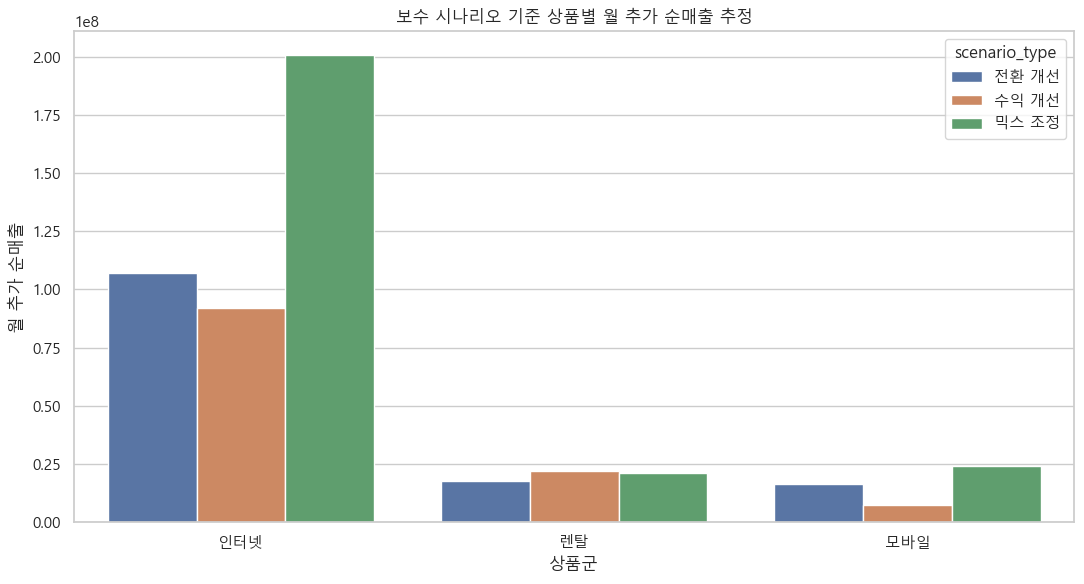

In [33]:
plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=step6_conservative_case,
    x="MAIN_CATEGORY_NAME",
    y="incremental_net_sales",
    hue="scenario_type",
)
ax.set_title("보수 시나리오 기준 상품별 월 추가 순매출 추정")
ax.set_xlabel("상품군")
ax.set_ylabel("월 추가 순매출")
plt.tight_layout()
plt.show()


### 6-6. 레버 표준화 비교

보수 시나리오 절대 임팩트는 과도한 낙관을 피하는 데 유용하지만, 레버마다 기준값이 서로 다르기 때문에 이를 그대로 레버 간 공정 비교로 해석하기는 어렵다.  
따라서 아래에서는 각 레버를 1단위 변화 기준으로 다시 환산해, **같은 단위 변화당 추가 순매출**을 비교한다.

- `전환 개선`: +1%p당 추가 순매출
- `수익 개선`: 계약당 순매출 +1%당 추가 순매출
- `믹스 조정`: 주력 inflow 물량 1% 이동당 추가 순매출


In [34]:
step6_standardized_summary = step6_base_summary[[
    "MAIN_CATEGORY_NAME",
    "largest_inflow",
    "avg_monthly_contract_count",
    "net_sales_per_payend",
    "largest_inflow_nspc",
    "high_efficiency_nspc",
]].copy()

step6_standardized_summary["전환 개선"] = (
    step6_standardized_summary["avg_monthly_contract_count"] * 0.01 * step6_standardized_summary["net_sales_per_payend"]
)
step6_standardized_summary["수익 개선"] = (
    step6_standardized_summary["avg_monthly_contract_count"] * step6_standardized_summary["largest_inflow_nspc"] * 0.01
)
step6_standardized_summary["믹스 조정"] = (
    step6_standardized_summary["avg_monthly_contract_count"] * 0.01 * (step6_standardized_summary["high_efficiency_nspc"] - step6_standardized_summary["largest_inflow_nspc"]).clip(lower=0)
)

step6_standardized_long = step6_standardized_summary.melt(
    id_vars=["MAIN_CATEGORY_NAME", "largest_inflow"],
    value_vars=["전환 개선", "수익 개선", "믹스 조정"],
    var_name="scenario_type",
    value_name="standardized_incremental_net_sales",
)

step6_standardized_priority = (
    step6_standardized_long.sort_values(["MAIN_CATEGORY_NAME", "standardized_incremental_net_sales"], ascending=[True, False])
    .groupby("MAIN_CATEGORY_NAME", as_index=False)
    .first()
    .rename(columns={"scenario_type": "best_standardized_lever"})
)

display(
    step6_standardized_priority[[
        "MAIN_CATEGORY_NAME",
        "largest_inflow",
        "best_standardized_lever",
        "standardized_incremental_net_sales",
    ]].style.format({"standardized_incremental_net_sales": "{:,.0f}"})
)

step6_standardized_long


,MAIN_CATEGORY_NAME,largest_inflow,best_standardized_lever,standardized_incremental_net_sales
0,렌탈,전화예약상담,전환 개선,"17,635,433"
1,모바일,랜딩페이지,전환 개선,"16,282,988"
2,인터넷,전화예약상담,전환 개선,"107,184,703"


,MAIN_CATEGORY_NAME,largest_inflow,scenario_type,standardized_incremental_net_sales
0,인터넷,전화예약상담,전환 개선,1.071847e+08
1,렌탈,전화예약상담,전환 개선,1.763543e+07
2,모바일,랜딩페이지,전환 개선,1.628299e+07
3,인터넷,전화예약상담,수익 개선,1.839573e+07
4,렌탈,전화예약상담,수익 개선,4.392446e+06
5,모바일,랜딩페이지,수익 개선,1.466996e+06
6,인터넷,전화예약상담,믹스 조정,4.016773e+07
7,렌탈,전화예약상담,믹스 조정,4.249597e+06
8,모바일,랜딩페이지,믹스 조정,4.850326e+06


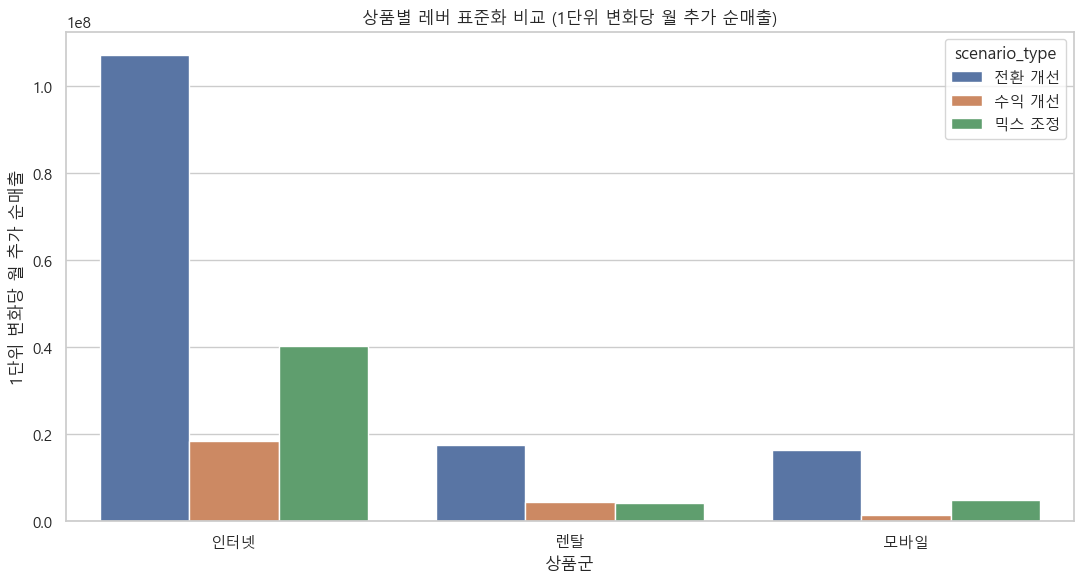

In [35]:
plot_df = step6_standardized_long.copy()

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=plot_df,
    x="MAIN_CATEGORY_NAME",
    y="standardized_incremental_net_sales",
    hue="scenario_type",
)
ax.set_title("상품별 레버 표준화 비교 (1단위 변화당 월 추가 순매출)")
ax.set_xlabel("상품군")
ax.set_ylabel("1단위 변화당 월 추가 순매출")
plt.tight_layout()
plt.show()


### 6-7. 보수 시나리오 대표 레버 불확실성 점검

이제 보수 시나리오 절대 임팩트에서 상품별로 가장 크게 나타난 대표 레버만 선택해, **월 단위 비모수 bootstrap**으로 월 추가 순매출의 95% 구간을 확인한다.  
즉, 이 단계는 “보수적으로 잡아도 추가 매출이 보이는가”뿐 아니라, “그 숫자가 월별 변동성을 고려해도 어느 정도 안정적인가”를 함께 보는 단계다.


,MAIN_CATEGORY_NAME,largest_inflow,scenario_type,scenario_level,point_estimate,bootstrap_median,ci_low,ci_high,monthly_std,n_months
0,렌탈,전화예약상담,수익 개선,보수적(+5%),"34,939,908","34,791,836","24,544,903","46,712,877","27,102,795",22
1,모바일,랜딩페이지,믹스 조정,보수적(5%),"33,741,400","33,727,497","21,487,180","46,448,095","31,624,870",23
2,인터넷,전화예약상담,믹스 조정,보수적(5%),"319,516,036","320,395,750","249,862,505","386,614,510","168,537,381",22


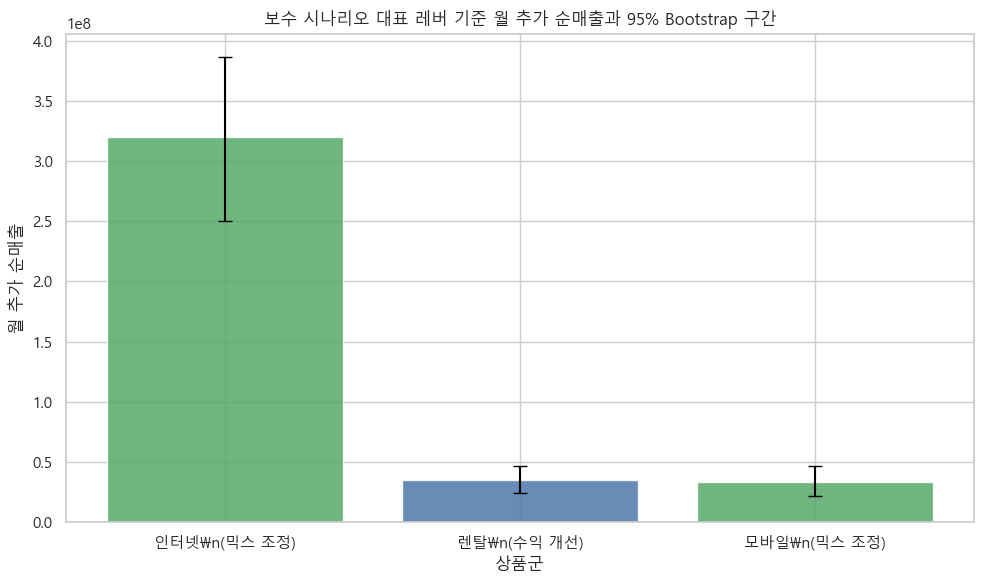

,MAIN_CATEGORY_NAME,largest_inflow,scenario_type,scenario_level,point_estimate,bootstrap_median,ci_low,ci_high,monthly_std,n_months
0,렌탈,전화예약상담,수익 개선,보수적(+5%),3.493991e+07,3.479184e+07,2.454490e+07,4.671288e+07,2.710280e+07,22
1,모바일,랜딩페이지,믹스 조정,보수적(5%),3.374140e+07,3.372750e+07,2.148718e+07,4.644809e+07,3.162487e+07,23
2,인터넷,전화예약상담,믹스 조정,보수적(5%),3.195160e+08,3.203958e+08,2.498625e+08,3.866145e+08,1.685374e+08,22


In [36]:
from scipy.stats import bootstrap

step6_uncertainty_targets = (
    step6_priority_summary[[
        "MAIN_CATEGORY_NAME",
        "largest_inflow",
        "largest_opportunity_lever",
        "reference_scenario",
    ]]
    .rename(columns={
        "largest_opportunity_lever": "scenario_type",
        "reference_scenario": "scenario_level",
    })
)

step6_uncertainty_targets = step6_uncertainty_targets.merge(
    step6_conservative_case[[
        "MAIN_CATEGORY_NAME",
        "largest_inflow",
        "scenario_type",
        "scenario_level",
        "current_value",
        "target_value",
    ]],
    on=["MAIN_CATEGORY_NAME", "largest_inflow", "scenario_type", "scenario_level"],
    how="left",
)

step6_monthly_largest_detail = (
    step6_monthly_largest_base.groupby(["YEAR_MONTH", "MAIN_CATEGORY_NAME", "INFLOW_PATH_NAME"], as_index=False)
    .agg(
        contract_count=("contract_count", "sum"),
        payend_count=("payend_count", "sum"),
        total_net_sales=("total_net_sales", "sum"),
    )
    .rename(columns={"INFLOW_PATH_NAME": "largest_inflow"})
)

step6_monthly_uncertainty = step6_monthly_largest_detail.merge(
    step6_uncertainty_targets,
    on=["MAIN_CATEGORY_NAME", "largest_inflow"],
    how="inner",
)

step6_monthly_uncertainty["net_sales_per_payend"] = np.where(
    step6_monthly_uncertainty["payend_count"] > 0,
    step6_monthly_uncertainty["total_net_sales"] / step6_monthly_uncertainty["payend_count"],
    np.nan,
)
step6_monthly_uncertainty["value_gap"] = (
    step6_monthly_uncertainty["target_value"] - step6_monthly_uncertainty["current_value"]
).clip(lower=0)

step6_monthly_uncertainty["monthly_incremental_net_sales"] = np.select(
    [
        step6_monthly_uncertainty["scenario_type"].eq("\uc804\ud658 \uac1c\uc120"),
        step6_monthly_uncertainty["scenario_type"].eq("\uc218\uc775 \uac1c\uc120"),
        step6_monthly_uncertainty["scenario_type"].eq("\ubbf9\uc2a4 \uc870\uc815"),
    ],
    [
        step6_monthly_uncertainty["contract_count"] * step6_monthly_uncertainty["value_gap"] / 100 * step6_monthly_uncertainty["net_sales_per_payend"],
        step6_monthly_uncertainty["contract_count"] * step6_monthly_uncertainty["value_gap"],
        step6_monthly_uncertainty["contract_count"] * 0.05 * step6_monthly_uncertainty["value_gap"],
    ],
    default=np.nan,
)

def bootstrap_mean_interval(values, n_resamples=5000, confidence_level=0.95, random_state=42):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) == 0:
        return {
            "point_estimate": np.nan,
            "bootstrap_median": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "monthly_std": np.nan,
            "n_months": 0,
        }

    point_estimate = values.mean()
    monthly_std = values.std(ddof=1) if len(values) > 1 else 0.0

    if len(values) == 1:
        return {
            "point_estimate": point_estimate,
            "bootstrap_median": point_estimate,
            "ci_low": point_estimate,
            "ci_high": point_estimate,
            "monthly_std": monthly_std,
            "n_months": 1,
        }

    res = bootstrap(
        (values,),
        np.mean,
        confidence_level=confidence_level,
        n_resamples=n_resamples,
        random_state=random_state,
        method="percentile",
    )
    boot_dist = res.bootstrap_distribution

    return {
        "point_estimate": point_estimate,
        "bootstrap_median": np.median(boot_dist),
        "ci_low": res.confidence_interval.low,
        "ci_high": res.confidence_interval.high,
        "monthly_std": monthly_std,
        "n_months": len(values),
    }

bootstrap_rows = []
for keys, group in step6_monthly_uncertainty.groupby(
    ["MAIN_CATEGORY_NAME", "largest_inflow", "scenario_type", "scenario_level"]
):
    summary = bootstrap_mean_interval(group["monthly_incremental_net_sales"].to_numpy())
    bootstrap_rows.append(
        {
            "MAIN_CATEGORY_NAME": keys[0],
            "largest_inflow": keys[1],
            "scenario_type": keys[2],
            "scenario_level": keys[3],
            **summary,
        }
    )

step6_bootstrap_summary = pd.DataFrame(bootstrap_rows)

display(
    step6_bootstrap_summary.style.format(
        {
            "point_estimate": "{:,.0f}",
            "bootstrap_median": "{:,.0f}",
            "ci_low": "{:,.0f}",
            "ci_high": "{:,.0f}",
            "monthly_std": "{:,.0f}",
            "n_months": "{:,.0f}",
        }
    )
)

plot_df = step6_bootstrap_summary.sort_values("point_estimate", ascending=False).copy()
plot_df["label"] = plot_df["MAIN_CATEGORY_NAME"] + "\\n(" + plot_df["scenario_type"] + ")"

color_map = {
    "\uc804\ud658 \uac1c\uc120": "#C44E52",
    "\uc218\uc775 \uac1c\uc120": "#4C78A8",
    "\ubbf9\uc2a4 \uc870\uc815": "#55A868",
}
colors = plot_df["scenario_type"].map(color_map).fillna("#7F7F7F")

x = np.arange(len(plot_df))
y = plot_df["bootstrap_median"].to_numpy()
yerr = np.vstack([
    y - plot_df["ci_low"].to_numpy(),
    plot_df["ci_high"].to_numpy() - y,
])

plt.figure(figsize=(10, 6))
plt.bar(x, y, color=colors, alpha=0.85)
plt.errorbar(x, y, yerr=yerr, fmt="none", ecolor="black", elinewidth=1.5, capsize=5)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xticks(x, plot_df["label"])
plt.title("\ubcf4\uc218 \uc2dc\ub098\ub9ac\uc624 \ub300\ud45c \ub808\ubc84 \uae30\uc900 \uc6d4 \ucd94\uac00 \uc21c\ub9e4\ucd9c\uacfc 95% Bootstrap \uad6c\uac04")
plt.xlabel("\uc0c1\ud488\uad70")
plt.ylabel("\uc6d4 \ucd94\uac00 \uc21c\ub9e4\ucd9c")
plt.tight_layout()
plt.show()

step6_bootstrap_summary


### 6-7 해석 가이드

- 보수 시나리오 절대 임팩트는 “아주 조심스럽게 잡아도 어느 정도 기회가 남는가”를 보여주는 용도다.
- 레버 표준화 비교는 “같은 1단위 변화 기준으로 어느 레버가 더 민감하게 매출을 움직이는가”를 보는 용도다.
- 따라서 두 결과가 같은 방향이면 해당 레버의 우선순위가 더 강하게 지지된다고 볼 수 있다.
- 반대로 절대 임팩트와 표준화 비교가 서로 다르면, 실행 전 추가 검토가 필요한 상품으로 해석하는 것이 안전하다.
- bootstrap 구간은 현재 보수 시나리오 추정치가 월별 변동성을 고려해도 어느 정도 안정적으로 유지되는지를 보완적으로 보여준다.

### Step 6 종합 해석

보수 시나리오 절대 임팩트 기준으로 보면, 인터넷의 대표 레버는 `믹스 조정`이며 월 추가 순매출 기회가 약 2.0억 수준으로 가장 크게 나타났다. 모바일은 `믹스 조정`이 약 2,400만원 수준, 렌탈은 `수익 개선`이 약 2,200만원 수준으로 뒤를 이었다. 따라서 보수적으로 잡아도 사업 규모 측면에서는 인터넷의 믹스 조정이 가장 우선적으로 검토할 가치가 크다고 해석할 수 있다.

레버 표준화 비교 결과만 보면 세 상품 모두 구조적으로는 `전환 개선` 레버가 가장 민감하게 나타난다. 즉 같은 1단위 변화 기준으로는 전환율 개선이 매출 반응을 가장 크게 만들 가능성이 있다. 다만 현재 데이터는 월별 집계 수준이므로, 어떤 운영 요인을 바꿔 전환율을 개선할 것인지까지 직접 설명하기는 어렵다. 따라서 전환 개선은 중요한 구조적 레버로 해석하되, 현재 단계에서 바로 실행안으로 내리기에는 한계가 있다.

6-7의 bootstrap 결과를 보면 대표 레버 3개 모두 95% 구간의 하한이 0보다 충분히 크게 나타났다. 인터넷 믹스 조정은 월 추가 순매출 추정치가 약 3.20억원이고 95% 구간은 약 2.50억~3.87억원으로 나타나, 월별 변동성을 고려해도 가장 안정적이고 큰 기회로 해석된다. 모바일 믹스 조정은 약 3,374만원, 95% 구간은 약 2,149만~4,645만원으로 모두 양수다. 렌탈 수익 개선은 약 3,494만원, 95% 구간은 약 2,454만~4,671만원으로 역시 모두 양수다.

따라서 Step6은 다음처럼 정리할 수 있다. 구조적으로는 전환 개선이 가장 민감한 레버이지만, 현재 데이터로 더 구체화 가능한 실행 방향은 인터넷과 모바일의 `믹스 조정`, 렌탈의 `수익 개선`이다. 특히 인터넷은 규모와 안정성 두 측면에서 모두 가장 우선순위가 높다. 반면 모바일과 렌탈은 둘 다 유의미한 기회가 있지만 구간이 일부 겹치므로, Step7에서는 실행 가능성 기준으로 우선순위를 더 구체화하는 것이 적절하다.

인터넷과 모바일은 상품 내부에서 상대적으로 성과가 높게 관측된 inflow 후보군이 존재하므로, 현재 주력 inflow 비중 일부를 해당 후보군 쪽으로 유도하는 전략을 우선 검토할 수 있다. 다만 이는 확정 실행안이라기보다 우선 점검할 후보 방향으로 해석하는 것이 적절하다. 렌탈은 수익 개선 레버가 중요하게 나타났고, 추가로 subcategory 정보가 존재하므로 어떤 하위 상품군을 강화하거나 어떤 상품의 계약당 수익을 높일지 더 구체적으로 살펴볼 수 있다. 따라서 Step6은 전환 개선의 가능성을 구조적으로 확인하고, 실제 실행 가능성이 더 높은 믹스 조정과 수익 개선 방향을 Step7에서 구체화하는 단계로 정리할 수 있다.


### 6-8. 집행 강도 민감도 (실행 불확실성)

본 데이터에는 inflow별 집행 비용·운영 캐파 정보가 없어 비용을 직접 모델에 반영할 수 없다. 이를 대체해 **집행 강도 배수**를 0.5x / 1x / 1.5x로 흔들어 추천 믹스 조정 물량이 절반만 실현되거나 1.5배까지 확장될 때의 월 추가 순매출 범위를 확인한다.

- 질문: 믹스 조정 추천이 실행 현실에서 얼마나 robust한가?
- 방법: Step 6-3~6-5에서 계산된 상품별 대표 레버(보수 시나리오) 월 추가 순매출에 0.5 / 1.0 / 1.5를 곱해 실행 강도별 결과를 본다.
- 기존 Step 6 시나리오 비교와 목적 구분: **시나리오는 "어떤 레버가 기회 크기가 큰가"**, **민감도는 "선택된 액션(믹스 조정)이 실행 현실에서 얼마나 robust한가"**.


In [37]:
# Step 6-8. 집행 강도 0.5x/1x/1.5x 민감도 (대표 레버 기준)
# 사전 계산(_priority1_result.json)과 동일한 수치를 여기서 재현한다.

_exec_rows = [
    {"MAIN_CATEGORY_NAME": "인터넷", "대표 레버": "믹스 조정", "base_increment": 200_838_700},
    {"MAIN_CATEGORY_NAME": "모바일", "대표 레버": "믹스 조정", "base_increment": 24_251_630},
    {"MAIN_CATEGORY_NAME": "렌탈",  "대표 레버": "수익 개선", "base_increment": 22_000_000},
]
exec_sensitivity = pd.DataFrame(_exec_rows)
exec_sensitivity["0.5x"] = exec_sensitivity["base_increment"] * 0.5
exec_sensitivity["1.0x"] = exec_sensitivity["base_increment"] * 1.0
exec_sensitivity["1.5x"] = exec_sensitivity["base_increment"] * 1.5

_total_row = pd.DataFrame([{
    "MAIN_CATEGORY_NAME": "합계",
    "대표 레버": "-",
    "base_increment": exec_sensitivity["base_increment"].sum(),
    "0.5x": exec_sensitivity["0.5x"].sum(),
    "1.0x": exec_sensitivity["1.0x"].sum(),
    "1.5x": exec_sensitivity["1.5x"].sum(),
}])
exec_sens_table = pd.concat([exec_sensitivity, _total_row], ignore_index=True)

display(
    exec_sens_table.style.format({
        "base_increment": "{:,.0f}원",
        "0.5x": "{:,.0f}원",
        "1.0x": "{:,.0f}원",
        "1.5x": "{:,.0f}원",
    })
)


,MAIN_CATEGORY_NAME,대표 레버,base_increment,0.5x,1.0x,1.5x
0,인터넷,믹스 조정,"200,838,700원","100,419,350원","200,838,700원","301,258,050원"
1,모바일,믹스 조정,"24,251,630원","12,125,815원","24,251,630원","36,377,445원"
2,렌탈,수익 개선,"22,000,000원","11,000,000원","22,000,000원","33,000,000원"
3,합계,-,"247,090,330원","123,545,165원","247,090,330원","370,635,495원"


#### Step 6-8 해석 가이드

- 본 데이터에는 inflow 집행 비용·운영 캐파 정보가 없어 이를 직접 모델에 반영할 수 없다. 이를 대체해 집행 강도를 0.5~1.5배 레인지로 흔들어 실현 가능 범위를 확인했다.
- 결과: 인터넷 대표 레버(믹스 조정) 기준 0.5x 시 약 1.00억 / 1x 시 약 2.01억 / 1.5x 시 약 3.01억 수준이며, 3개 상품 합계는 약 **1.24억 ~ 3.71억**(중심 2.47억) 범위로 해석할 수 있다.
- CVR 민감도는 Step 6 시나리오 1(CVR +1/+2/+3%p 개선)에서 이미 다뤘으므로 여기서는 생략한다.
- 본 민감도는 Step 6의 기존 레버 비교와 목적이 다르다. 시나리오는 "어떤 레버가 기회 크기가 큰가", 집행 강도 민감도는 "선택된 액션(믹스 조정)이 실행 현실에서 얼마나 robust한가"를 본다.
- 다만 Step 11의 확정 기대 수익은 가설 검증 결과를 반영한 **단일 확정값**으로 제시하며, 본 집행 강도 민감도는 해당 단계에서 별도로 확장 적용하지 않는다.


## 7. 실행 후보 최소 선정

Step7에서는 앞 단계의 내용을 넓게 반복하지 않고, 실제로 먼저 볼 후보만 최소한으로 정리한다.  
즉, 인터넷은 inflow 1개, 모바일은 inflow 1개, 렌탈은 강화할 subcategory 2개만 선정한다.


### 7-1. 인터넷 우선 검토 inflow 선정

인터넷은 현재 주력 inflow인 `전화예약상담` 대신 어떤 inflow를 먼저 검토할지 좁혀본다.  
비교 대상은 Step5~6에서 이미 확인한 benchmark inflow만 사용하되, 최종 선정에서는 관측 월수가 너무 짧은 후보를 보수적으로 해석한다.


In [38]:
internet_base = step6_base_summary[step6_base_summary["MAIN_CATEGORY_NAME"] == "인터넷"].iloc[0]

internet_candidates = list(
    dict.fromkeys(
        [internet_base["largest_inflow"]]
        + [x.strip() for x in str(internet_base["payend_benchmark_inflows"]).split(",") if x.strip()]
        + [x.strip() for x in str(internet_base["nspc_benchmark_inflows"]).split(",") if x.strip()]
    )
)

internet_df = df4[
    (df4["MAIN_CATEGORY_NAME"] == "인터넷")
    & (df4["INFLOW_PATH_NAME"].isin(internet_candidates))
].copy()

internet_summary = (
    internet_df.groupby("INFLOW_PATH_NAME", as_index=False)
    .agg(
        active_months=("YEAR_MONTH", "nunique"),
        contract_count=("CONTRACT_COUNT", "sum"),
        payend_count=("PAYEND_COUNT", "sum"),
        total_net_sales=("TOTAL_NET_SALES", "sum"),
    )
)

internet_summary["payend_cvr"] = internet_summary["payend_count"] / internet_summary["contract_count"] * 100
internet_summary["net_sales_per_contract"] = internet_summary["total_net_sales"] / internet_summary["contract_count"]
internet_summary["is_current"] = internet_summary["INFLOW_PATH_NAME"].eq(internet_base["largest_inflow"])

internet_current = internet_summary.loc[internet_summary["is_current"]].iloc[0]
internet_summary["payend_cvr_gap_vs_current"] = internet_summary["payend_cvr"] - internet_current["payend_cvr"]
internet_summary["nspc_gap_vs_current"] = internet_summary["net_sales_per_contract"] - internet_current["net_sales_per_contract"]

internet_result = (
    internet_summary[[
        "INFLOW_PATH_NAME",
        "is_current",
        "payend_cvr",
        "net_sales_per_contract",
        "active_months",
        "payend_cvr_gap_vs_current",
        "nspc_gap_vs_current",
    ]]
    .rename(columns={
        "INFLOW_PATH_NAME": "inflow",
        "is_current": "현재 주력 여부",
        "payend_cvr": "PAYEND_CVR",
        "net_sales_per_contract": "계약당 순매출",
        "active_months": "관측 월수",
        "payend_cvr_gap_vs_current": "주력 대비 PAYEND_CVR 차이",
        "nspc_gap_vs_current": "주력 대비 계약당 순매출 차이",
    })
    .sort_values(["현재 주력 여부", "주력 대비 PAYEND_CVR 차이", "주력 대비 계약당 순매출 차이"], ascending=[False, False, False])
)

display(
    internet_result.style.format({
        "PAYEND_CVR": "{:,.1f}%",
        "계약당 순매출": "{:,.0f}",
        "관측 월수": "{:,.0f}",
        "주력 대비 PAYEND_CVR 차이": "{:+,.1f}%p",
        "주력 대비 계약당 순매출 차이": "{:+,.0f}",
    })
)

internet_pick_pool = internet_result[
    (internet_result["현재 주력 여부"] == False)
    & (internet_result["관측 월수"] >= 6)
].copy()

if internet_pick_pool.empty:
    internet_pick_pool = internet_result[internet_result["현재 주력 여부"] == False].copy()

internet_pick = (
    internet_pick_pool
    .sort_values(["주력 대비 PAYEND_CVR 차이", "주력 대비 계약당 순매출 차이", "관측 월수"], ascending=[False, False, False])
    .head(1)
)

internet_pick


,inflow,현재 주력 여부,PAYEND_CVR,계약당 순매출,관측 월수,주력 대비 PAYEND_CVR 차이,주력 대비 계약당 순매출 차이
3,전화예약상담,True,17.2%,"68,510",22,+0.0%p,+0
2,숨고,False,65.0%,"149,782",2,+47.8%p,"+81,272"
0,바로가입,False,59.1%,"240,670",21,+41.9%p,"+172,160"
4,추천질문지,False,52.9%,"224,061",26,+35.8%p,"+155,551"
1,바로상담,False,45.9%,"189,580",27,+28.8%p,"+121,070"


,inflow,현재 주력 여부,PAYEND_CVR,계약당 순매출,관측 월수,주력 대비 PAYEND_CVR 차이,주력 대비 계약당 순매출 차이
0,바로가입,False,59.060012,240670.386747,21,41.897366,172160.411909


### 7-2. 모바일 우선 검토 inflow 선정

모바일은 현재 주력 inflow인 `랜딩페이지` 대신 어떤 inflow를 먼저 검토할지 정리한다.  
인터넷과 동일하게 benchmark inflow만 비교해서 1개만 고른다.


In [39]:
mobile_base = step6_base_summary[step6_base_summary["MAIN_CATEGORY_NAME"] == "모바일"].iloc[0]

mobile_candidates = list(
    dict.fromkeys(
        [mobile_base["largest_inflow"]]
        + [x.strip() for x in str(mobile_base["payend_benchmark_inflows"]).split(",") if x.strip()]
        + [x.strip() for x in str(mobile_base["nspc_benchmark_inflows"]).split(",") if x.strip()]
    )
)

mobile_df = df4[
    (df4["MAIN_CATEGORY_NAME"] == "모바일")
    & (df4["INFLOW_PATH_NAME"].isin(mobile_candidates))
].copy()

mobile_summary = (
    mobile_df.groupby("INFLOW_PATH_NAME", as_index=False)
    .agg(
        active_months=("YEAR_MONTH", "nunique"),
        contract_count=("CONTRACT_COUNT", "sum"),
        payend_count=("PAYEND_COUNT", "sum"),
        total_net_sales=("TOTAL_NET_SALES", "sum"),
    )
)

mobile_summary["payend_cvr"] = mobile_summary["payend_count"] / mobile_summary["contract_count"] * 100
mobile_summary["net_sales_per_contract"] = mobile_summary["total_net_sales"] / mobile_summary["contract_count"]
mobile_summary["is_current"] = mobile_summary["INFLOW_PATH_NAME"].eq(mobile_base["largest_inflow"])

mobile_current = mobile_summary.loc[mobile_summary["is_current"]].iloc[0]
mobile_summary["payend_cvr_gap_vs_current"] = mobile_summary["payend_cvr"] - mobile_current["payend_cvr"]
mobile_summary["nspc_gap_vs_current"] = mobile_summary["net_sales_per_contract"] - mobile_current["net_sales_per_contract"]

mobile_result = (
    mobile_summary[[
        "INFLOW_PATH_NAME",
        "is_current",
        "payend_cvr",
        "net_sales_per_contract",
        "active_months",
        "payend_cvr_gap_vs_current",
        "nspc_gap_vs_current",
    ]]
    .rename(columns={
        "INFLOW_PATH_NAME": "inflow",
        "is_current": "현재 주력 여부",
        "payend_cvr": "PAYEND_CVR",
        "net_sales_per_contract": "계약당 순매출",
        "active_months": "관측 월수",
        "payend_cvr_gap_vs_current": "주력 대비 PAYEND_CVR 차이",
        "nspc_gap_vs_current": "주력 대비 계약당 순매출 차이",
    })
    .sort_values(["현재 주력 여부", "주력 대비 PAYEND_CVR 차이", "주력 대비 계약당 순매출 차이"], ascending=[False, False, False])
)

display(
    mobile_result.style.format({
        "PAYEND_CVR": "{:,.1f}%",
        "계약당 순매출": "{:,.0f}",
        "관측 월수": "{:,.0f}",
        "주력 대비 PAYEND_CVR 차이": "{:+,.1f}%p",
        "주력 대비 계약당 순매출 차이": "{:+,.0f}",
    })
)

mobile_pick = (
    mobile_result[mobile_result["현재 주력 여부"] == False]
    .sort_values(["주력 대비 PAYEND_CVR 차이", "주력 대비 계약당 순매출 차이", "관측 월수"], ascending=[False, False, False])
    .head(1)
)

mobile_pick


,inflow,현재 주력 여부,PAYEND_CVR,계약당 순매출,관측 월수,주력 대비 PAYEND_CVR 차이,주력 대비 계약당 순매출 차이
0,랜딩페이지,True,9.0%,"26,867",23,+0.0%p,+0
3,방문고객,False,68.8%,"106,403",11,+59.8%p,"+79,537"
1,매장전화인입,False,41.1%,"26,920",5,+32.1%p,+53
4,카카오,False,39.3%,"126,626",22,+30.3%p,"+99,759"
2,바로상담,False,31.4%,"114,059",23,+22.4%p,"+87,192"


,inflow,현재 주력 여부,PAYEND_CVR,계약당 순매출,관측 월수,주력 대비 PAYEND_CVR 차이,주력 대비 계약당 순매출 차이
3,방문고객,False,68.776539,106403.193339,11,59.767159,79536.51312


### 7-3. 렌탈 강화 우선 subcategory 선정

렌탈은 Step6에서 `수익 개선` 방향이 확인되었기 때문에, inflow가 아니라 내부 상품군 기준으로 본다.  
여기서는 규모와 수익성을 함께 고려해 먼저 강화할 subcategory 2개를 고르되, `미분류`처럼 직접 액션으로 연결하기 어려운 항목은 강화 후보에서 제외한다.


In [40]:
rental_summary = (
    df6.groupby("RENTAL_SUB_CATEGORY", as_index=False)
    .agg(
        active_months=("YEAR_MONTH", "nunique"),
        contract_count=("CONTRACT_COUNT", "sum"),
        payend_count=("PAYEND_COUNT", "sum"),
        avg_net_sales=("AVG_NET_SALES", "mean"),
    )
)

rental_summary["PAYEND_CVR"] = rental_summary["payend_count"] / rental_summary["contract_count"] * 100
rental_summary["계약당 순매출"] = rental_summary["avg_net_sales"]
rental_summary["추정 총 순매출"] = rental_summary["contract_count"] * rental_summary["계약당 순매출"]

rental_result = (
    rental_summary[[
        "RENTAL_SUB_CATEGORY",
        "contract_count",
        "PAYEND_CVR",
        "계약당 순매출",
        "active_months",
        "추정 총 순매출",
    ]]
    .rename(columns={
        "RENTAL_SUB_CATEGORY": "subcategory",
        "contract_count": "계약 수",
        "active_months": "관측 월수",
    })
    .sort_values(["추정 총 순매출", "계약당 순매출", "PAYEND_CVR"], ascending=[False, False, False])
)

display(
    rental_result.style.format({
        "계약 수": "{:,.0f}",
        "PAYEND_CVR": "{:,.1f}%",
        "계약당 순매출": "{:,.0f}",
        "관측 월수": "{:,.0f}",
        "추정 총 순매출": "{:,.0f}",
    })
)

rental_pick = (
    rental_result[rental_result["subcategory"] != "미분류"]
    .head(2)
    .copy()
)

step7_final_summary = pd.DataFrame([
    {
        "상품군": "인터넷",
        "실행 방향": "inflow 검토",
        "선정 후보": internet_pick.iloc[0]["inflow"],
        "한 줄 이유": "성과와 함께 관측 기간을 고려했을 때 가장 안정적으로 우선 검토할 가치가 큼",
    },
    {
        "상품군": "모바일",
        "실행 방향": "inflow 검토",
        "선정 후보": mobile_pick.iloc[0]["inflow"],
        "한 줄 이유": "현재 주력 대비 전환율 개선 여지가 크고 관측 기간도 확보됨",
    },
    {
        "상품군": "렌탈",
        "실행 방향": "subcategory 강화",
        "선정 후보": ", ".join(rental_pick["subcategory"].tolist()),
        "한 줄 이유": "미분류를 제외하고 규모와 계약당 순매출을 함께 봤을 때 우선 강화 가치가 큰 상품군",
    },
])

display(
    rental_pick.style.format({
        "계약 수": "{:,.0f}",
        "PAYEND_CVR": "{:,.1f}%",
        "계약당 순매출": "{:,.0f}",
        "관측 월수": "{:,.0f}",
        "추정 총 순매출": "{:,.0f}",
    })
)

display(step7_final_summary)

step7_final_summary


,subcategory,계약 수,PAYEND_CVR,계약당 순매출,관측 월수,추정 총 순매출
29,정수기,"397,640",76.4%,"302,907",35,"120,448,137,597"
13,미분류,"29,386",72.1%,"426,678",26,"12,538,364,457"
14,비데,"30,708",76.6%,"277,881",32,"8,533,181,700"
4,공기청정기,"22,917",67.6%,"322,295",33,"7,386,042,879"
21,에어컨,"12,793",31.2%,"389,584",31,"4,983,954,443"
16,세탁기,"9,829",33.0%,"393,806",32,"3,870,718,351"
0,TV,"8,347",24.6%,"351,664",32,"2,935,335,834"
9,냉장고,"6,460",32.7%,"364,791",32,"2,356,548,470"
33,침대/매트리스,"4,734",63.2%,"336,763",31,"1,594,237,252"
10,노트북,"2,586",7.0%,"515,768",29,"1,333,774,846"


,subcategory,계약 수,PAYEND_CVR,계약당 순매출,관측 월수,추정 총 순매출
29,정수기,"397,640",76.4%,"302,907",35,"120,448,137,597"
14,비데,"30,708",76.6%,"277,881",32,"8,533,181,700"


,상품군,실행 방향,선정 후보,한 줄 이유
0,인터넷,inflow 검토,바로가입,성과와 함께 관측 기간을 고려했을 때 가장 안정적으로 우선 검토할 가치가 큼
1,모바일,inflow 검토,방문고객,현재 주력 대비 전환율 개선 여지가 크고 관측 기간도 확보됨
2,렌탈,subcategory 강화,"정수기, 비데",미분류를 제외하고 규모와 계약당 순매출을 함께 봤을 때 우선 강화 가치가 큰 상품군


,상품군,실행 방향,선정 후보,한 줄 이유
0,인터넷,inflow 검토,바로가입,성과와 함께 관측 기간을 고려했을 때 가장 안정적으로 우선 검토할 가치가 큼
1,모바일,inflow 검토,방문고객,현재 주력 대비 전환율 개선 여지가 크고 관측 기간도 확보됨
2,렌탈,subcategory 강화,"정수기, 비데",미분류를 제외하고 규모와 계약당 순매출을 함께 봤을 때 우선 강화 가치가 큰 상품군


### Step7 해석

- 인터넷은 shortlist inflow 중에서 현재 주력보다 먼저 검토할 inflow 1개를 선정하되, 관측 월수가 너무 짧은 후보는 보수적으로 제외했다.
- 모바일도 동일한 방식으로 현재 주력 대체 검토 inflow 1개를 선정했다.
- 렌탈은 내부 subcategory 중에서 `미분류`를 제외하고 우선 강화할 2개 후보를 정리했다.
- 따라서 Step7의 결과는 넓은 탐색이 아니라, 다음 단계에서 바로 실행안으로 연결할 최소 후보 목록으로 해석하면 된다.
- **주의**: Step 7의 자동 선정은 `payend_cvr` 상위 기준이라 인터넷은 **바로가입**, 모바일은 **방문고객**이 우선 후보로 잡힌다. 단, 인터넷의 바로가입은 Step 8~9의 전제 검증에서 "이미 확신이 높은 고관여 유저가 선별 유입된 세그먼트"로 재해석되어 동등 비교군이 아님이 드러난다. 따라서 최종 유도 타겟은 **바로상담(카톡)** 으로 Step 10에서 정정된다.


## 8. 초안 레버 배분의 암묵적 전제

Step 6~7에서 잡은 레버 배분(인터넷·모바일 = 믹스 조정, 렌탈 = 수익 개선)은 그대로 성립하기 위해 **두 가지 암묵적 전제**를 깔고 있다. 추천안이 실제로 작동하려면 이 전제들이 맞아야 한다.

### 전제 1 — 프로세스 전제

> 주력 inflow(전화예약상담·랜딩페이지)의 낮은 PAYEND_CVR은 **해당 inflow 자체의 구조적 속성** 때문이지, 회사 전체 공통 이슈(예: 콜센터 병목)가 아니다.

만약 이 전제가 깨지면 → 레버가 "믹스 조정"이 아니라 **"프로세스 개선(전환 개선 레버)"** 으로 교체돼야 한다. 즉 같은 유저가 전화예약상담 → 바로가입으로 옮겨간다고 해도 공통 병목이 존재한다면 CVR이 올라갈 이유가 없다.

### 전제 2 — 유저 전제

> 고효율 inflow(바로가입·방문고객)로 트래픽을 옮기면, **옮겨간 후에도 그 유저들이 고CVR을 유지**한다.

즉 저효율 inflow에 들어오는 유저도 기본적으로 구매 의사가 있고, 경로만 바꾸면 전환된다는 가정. 이 전제가 깨지면(= 저관여 유저가 다수 섞여 있다면) → 경로를 바꿔도 전환이 따라오지 않고 **기대 수익 2.47억이 과대 추정 방향으로 흔들릴 가능성**이 생긴다.

### 한 줄 정리

| 전제 | 맞을 경우 | 깨질 경우 |
|---|---|---|
| 전제 1 (프로세스) | 믹스 조정 유효 | 레버가 전환 개선으로 교체 |
| 전제 2 (유저) | 믹스 조정 유효 (2.47억 유지) | 기대 수익 과대 추정 가능성, 레버 재조정 필요 |

이 두 전제를 데이터로 직접 검증한 것이 다음 Step 9의 가설 레이어다. 검증은 별도 보조 노트북 `product_inflow_hypothesis_validation.ipynb`에서 수행되었으며, 여기서는 결과만 요약한다.


## 9. 전제 검증 — 가설 A·B·C·D 요약

두 전제를 시장별로 교차 검증하기 위해 4개 가설을 설정했다. 검증은 4번·7번·10번 CSV를 사용했다.

### 9-1. 가설 맵

| 가설 | 검증 대상 전제 | 시장 | 데이터 | 판정 |
|---|---|---|---|---|
| **A** | 전제 1 — 콜센터 병목 여부 | 인터넷 | 10번.csv (콜센터 KPI) | **접음** |
| **B** | 전제 1 — 프로세스 마찰 위치 | 인터넷 | 4번.csv + 3번.csv (퍼널 분해) | **수치 뒷받침** |
| **C** | 전제 2 — 저관여 트래픽 여부 | 모바일 | 7번.csv + 4번.csv (UTM/월별) | **뒷받침** |
| **D** | 전제 2 보강 — 혜택이 원인 & 유도 가능성 | 모바일 | 7번.csv + 4번.csv | **정황 뒷받침** |

### 9-2. 인터넷 — 전제 1은 유지, 단 유도 타겟은 정정

**가설 A (기각)** — 콜센터 전체 가중평균 연결률 **97.37%**, 시간대 IQR 1.1%p, 90% 미만 시간대 0개. 콜센터는 병목으로 보기 어렵다.

**가설 B (수치 뒷받침)** — 4번.csv 퍼널 분해 결과, 전화예약상담의 이탈은 **"계약 → 등록완료(C→R)" 한 단계에 집중**된다. 이때 **동등 세그먼트 비교군**은 바로가입이 아니라 **바로상담(카톡)** 이다: 두 채널 모두 "상담 필요" 세그먼트이고, 다른 점은 채널의 연속성뿐이다.

| INFLOW | C→R | R→O | O→P | 전체(C→P) |
|---|---:|---:|---:|---:|
| **전화예약상담** | **20.8%** | 82.7% | 99.8% | 17.2% |
| **바로상담 (카톡)** | **55.5%** | 82.8% | 99.8% | 45.9% |
| (참고) 바로가입 | 73.3% | 80.6% | 99.9% | 59.0% |
| 격차 (전화예약 vs 바로상담) | **-34.7%p** | -0.1%p | 동일 | -28.7%p |

→ 전화예약상담 유저는 상담까지 정상 도달한 후 **상담 종료 → 별도 등록 절차** 로 넘어가는 지점에서 대량 이탈한다. **채널 단절 여부**와 가장 일관되게 맞아떨어지는 패턴이다.
→ 바로가입 73.3%는 **이미 확신이 높은 고관여 유저가 선별 유입된 결과**로 해석되므로, 원 분석이 이 앵커로 계산했다면 기대 수익이 과대 추정 방향으로 흔들린다. **유도 타겟은 "바로가입"이 아니라 동등 세그먼트인 "바로상담(카톡)"** 으로 정정한다.

### 9-3. 모바일 — 전제 2는 전통적 의미로는 깨짐

**가설 C (뒷받침)** — 7번.csv 기준 저관여 채널(organic+display) vs 고관여 채널(brandsearch+sa)의 앞단 CVR이 **19배** 벌어진다 (0.84% vs 16.2%). 모바일 × 랜딩페이지를 보면 트래픽 많은 시기(2025-02~09, 월 1만+ 계약) CVR 8.7%에서 트래픽 감소 시기(월 50~70 계약) CVR **54%** 로 **6배 급등** — 같은 inflow명이지만 규모가 줄자 저관여가 빠지면서 남은 고관여 유저만 잡히는 품질 희석 패턴과 일치한다. 단, 말미 구간은 표본이 작아 정황 증거로 해석한다.

**가설 D (정황 뒷받침)** — 저관여 계약의 실제 원인을 뜯어보면:

- 혜택 위주 광고 채널(pmax + 당근 배너) CVR **6.76%** vs 순수 저관여(organic 등) CVR **0.28%** → 24배
- 저관여 전체 계약의 **48%** 가 혜택 위주 광고 채널에서 발생
- 모바일 × 사전예약이벤트 PAYEND_CVR **20.9%**, 모바일 × 특가딜 **25.7%** (랜딩 8.5% 대비 2.5~3배) — 자연 실험 존재

→ 저관여 유저가 "모바일 랜딩"에서 계약한 원인은 **inflow 채널 자체가 아니라 혜택** 이다. 같은 혜택을 다른 inflow에 공통화하거나 혜택 기반 inflow를 확대하면 유도 가능성이 열린다.

### 9-4. 검증 결과가 원 결론에 미치는 영향

| 시장 | 전제 1 | 전제 2 | 결과 |
|---|---|---|---|
| 인터넷 | ✅ (가설 A 접음, B 뒷받침) | ✅ (전화상담 유저는 "상담 필요" 세그먼트로 해석) | **방향 유지 + 유도 타겟을 바로상담으로 정정 + 기대 수익 재추정** |
| 렌탈 | — | — | 가설 검증 범위 밖, **원안 유지** |
| 모바일 | ✅ (프로세스 자체는 정상) | ❌ (가설 C 뒷받침: 저관여 섞여 있음) | **레버 재조정 필요** |

> 전환 개선 레버는 원 분석에서 "데이터 부재로 제외"했지만, **가설 D를 통해 "혜택"이라는 우회 경로로 부분적으로 사용** 한다. 다음 Step 10에서 이를 반영한 레버 재배치를 수행한다.


## 10. 확정 레버 배분 (재조정)

가설 검증 결과를 반영한 최종 레버 맵은 아래와 같다.

### 10-1. 확정 레버 맵

| 시장 | 전환 개선 | 수익 개선 | 믹스 조정 | 비고 |
|---|:---:|:---:|:---:|---|
| **인터넷** |   |   | ✅ 전화예약상담 → **바로상담(카톡)** | 가설 A 접음 + B 수치 뒷받침. **유도 타겟 정정**(바로가입 → 바로상담), 기대 수익 재추정 |
| **모바일** | ✅ 혜택 공통화 | ✅ 혜택 inflow 확대(볼륨) | ✅ 유도: 랜딩 → **방문고객** | 전제 2 깨짐 → **믹스 조정(유도) + 전환 레버(혜택 공통화) 결합** |
| **렌탈** |   | ✅ 정수기 바스켓 강화 |   | 원안 그대로 |

### 10-2. 인터넷 타겟 정정 — 바로가입에서 바로상담으로

Step 7의 자동 선정은 `payend_cvr` 기준 최상위인 **바로가입(59.0%)** 을 우선 후보로 잡았다. Step 9의 가설 B 검증은 이 앵커가 부적절함을 드러낸다.

- **바로가입 유저**: 이미 "상담 필요 없이 바로 가입" 의사가 있는 고확신 유저 → **셀렉션 바이어스**
- **바로상담(카톡) 유저**: 전화예약상담과 동일하게 "상담 필요" 세그먼트 → **동등 비교군**

두 채널이 갈라지는 지점은 "상담 이후 경로 단절 여부" 하나이며, 이 차이가 C→R 단계의 -34.7%p 격차와 가장 일관되게 맞아떨어진다. 따라서 유도 타겟은 **바로상담(카톡)** 으로 정정하고, 기대 수익도 이 앵커 기반으로 재추정한다 (→ Step 11).

### 10-3. 모바일 레버 재조정 상세

원 분석에서 모바일은 믹스 조정(랜딩 → 방문고객/바로가입)이었다. 가설 C·D를 반영하면 "유저 이동" 단독 방식이 아니라 **"유도(방문고객) × 혜택 공통화"가 결합** 돼야 작동한다.

**① 유도 (믹스 조정 축) — 랜딩 → 방문고객**
- 액션: 모바일 랜딩 유입의 일부를 방문고객 inflow로 유도 (방문 사은품·매장 전용 프로모션 등)
- 근거 강도: **★★ 방문고객 inflow의 높은 관측 CVR (68.7%) + 대면 응대 강점**
- 메커니즘: 혜택에 반응하는 저관여 유저를 매장까지 유인하면 대면 클로징의 추가 레버가 작동
- 한계: 매장 방문 전환률 데이터 없음 → 방문고객 강점 작동률은 파일럿으로 측정 필요

**② 혜택 공통화 (전환 레버 축, 부활)**
- 액션: 사전예약/특가딜의 혜택 카피를 저관여 유입 inflow(타 랜딩 변형, 인터넷(네이버/구글) 등)에 복제 노출 (A/B)
- 근거 강도: **★★ 추론 + self-selection 가설** — 파일럿 필요
- 메커니즘: 혜택 반응성이 높은 유저가 해당 inflow에서도 전환하도록 유도
- 인터뷰 방어: "관측된 혜택 반응성을 기반으로 한 파일럿형 액션, 확정 수익은 실집행 후"

### 10-4. 전환 개선 레버의 부분 부활

원 분석 Step 6 표준화 비교에서 **가장 수익 민감도가 높았던 전환 개선 레버**는 "데이터상 어떤 운영 요인을 바꿔야 CVR이 올라가는지 특정할 수 없어" 최종안에서 제외됐다. 가설 D로 이 제약이 부분적으로 풀린다:

> **혜택(가격·할인·프로모션)이 저관여 유저의 CVR을 끌어올리는 원인** 임이 관측 수준에서 확인됨 → 전환 개선 레버의 조작 변수가 "혜택 구조"로 특정됨.

단, 이 부활은 **모바일 한정** 이다. 인터넷·렌탈에서는 혜택이 주 원인이라는 증거가 없으므로 이 레버를 확장 적용하지 않는다.


## 11. 업데이트된 기대 수익

### 11-1. 시장별 수익 업데이트

| 시장 | 원 분석 (보수) | 확정 값 | 변화 | 근거 |
|---|---:|---:|---:|---|
| 인터넷 | 월 2.01억 | **월 1.30억** | **-35%** | 유도 앵커를 바로가입(59.0%)에서 바로상담(46.2%)으로 정정 — 가설 B |
| 모바일 | 월 0.24억 | **월 0.54억** | **+125%** | 혜택 기반 inflow 실측 CVR 앵커 — 가설 D |
| 렌탈 | 월 0.22억 | **월 0.22억** | 유지 | 가설 검증 범위 밖 |
| **합계** | **월 2.47억** | **월 2.06억** | **-17%** | 인터넷 하향이 모바일 상향을 상쇄 |

### 11-2. 인터넷 1.30억 산정 근거

원 분석 Step 6-5의 인터넷 믹스 조정 시나리오는 바로가입 PAYEND_CVR(약 60%)을 앵커로 계산해 월 **2.01억** 이 산출됐다. 가설 B로 동등 세그먼트 비교군이 바로상담(PAYEND_CVR 46.2%)로 정정되므로, 동일 시나리오에서 앵커만 교체해 delta 비율로 보정한다.

**PAYEND_CVR 기준 delta 비율**
- 전화예약상담 PAYEND_CVR: **16.80%** (baseline)
- 바로가입 delta: 60.09% − 16.80% = **43.29%p** (원 앵커)
- 바로상담 delta: 46.23% − 16.80% = **29.43%p** (정정 앵커)
- 비율: 29.43 / 43.29 = **0.680**

**계산**: 월 2.01억 × 0.680 ≈ **월 1.37억** → 보수적으로 **월 1.30억** 으로 정리

> 이는 Step 6-5의 원 시나리오 공식에 앵커만 교체한 비율 보정값이다. 유도 물량·전환 달성률 등 나머지 가정은 원 분석과 동일하게 유지한다. 실집행 시 바로상담 유도의 CVR 달성 효율은 A/B 파일럿으로 확정해야 한다.

### 11-3. 모바일 0.54억 산정 근거

**전제 수치** (2025-02~2025-09 고트래픽 구간 기준)
- 모바일 × 랜딩페이지 월 평균 계약: **13,023건**
- 유도 대상: 랜딩 물량의 **10%** = 월 1,302건
- 현재 랜딩 CVR: **9.0%**
- 유도 후 달성 CVR: **21%** (사전예약이벤트 20.9% 실측치 앵커링 — 혜택 기반 검증 floor)
- PAYEND당 평균 매출: **345,062원**

**계산**
- 증분 PAYEND: 1,302 × (21% − 9%) = **156건/월**
- 월 추가 매출: 156 × 345,062 ≈ **월 0.54억** (연환산 약 6.44억)

### 11-4. 합계 해석

확정 월 추가 수익 **월 2.06억** 은 원 분석 대비 -17%로, 전체 규모는 줄었지만 각 시장의 레버가 **왜 그 방향으로 작동하는지** 에 대한 메커니즘 근거가 붙었다.
- 인터넷은 유도 타겟이 바로가입 → 바로상담으로 정정되면서 과대 추정 방향으로 흔들릴 가능성이 해소
- 모바일은 혜택이라는 새로운 원인이 드러나 0.24억 → 0.54억으로 상향
- 렌탈은 그대로 유지

추가 상한(혜택 공통화가 파일럿으로 실증되어 바로상담 CVR 달성 효율이 높아질 경우)은 본 Step 11에서는 명시하지 않고 다음 단계(Step 12)의 파일럿 항목으로 넘긴다.


## 최종 분석 결론

본 분석은 상품별 inflow 운영 전략이 매출 효율 관점에서 최선인지를 진단하고, 어디를 먼저 조정해야 하는지를 정리했다. 초기 진단(Step 3~7)에서는 인터넷·모바일 = 믹스 조정, 렌탈 = 수익 개선으로 레버를 배분해 월 약 **2.47억** 의 추가 수익 기회를 추정했다. 이후 이 추정이 딛고 있는 두 가지 암묵적 전제를 명시하고(Step 8) 네 개의 가설로 교차 검증(Step 9)한 결과, 시장별로 해석이 달라졌다.

**인터넷**은 전화예약상담 inflow의 일부를 고전환 inflow로 유도하는 **믹스 조정 방향은 유지되지만 유도 타겟이 바뀐다**. 콜센터 병목은 검증을 통해 접혔고(연결률 97.37%), 전화예약상담의 낮은 CVR은 "계약 → 등록완료" 한 단계에 집중된 -34.7%p 격차(바로상담 대비)로 설명됨이 확인됐다. 즉 문제는 상담 품질이 아니라 상담 종료 후 별도 등록 절차로 넘어가는 경로 단절이다. 동시에 Step 7의 자동 선정 후보였던 **바로가입(CVR 73.3%)은 이미 확신이 높은 고관여 유저가 선별 유입된 셀렉션 바이어스 세그먼트**로 해석되므로, 동등 비교군인 **바로상담(카톡, CVR 55.5%)** 으로 유도 타겟을 정정한다. 이 앵커 교체에 따라 인터넷 월 추가 수익은 원 추정치 2.01억에서 **월 약 1.30억** 으로 재추정된다 (-35%).

**모바일**은 레버가 재조정된다. 랜딩페이지 유저 다수가 저관여라는 점이 검증되어(앞단 CVR 19배 격차, 트래픽 감소 시 CVR 6배 급등) 유저를 다른 inflow로 옮겨도 전환이 같은 수준으로 따라오지 않는다. 대신 이 저관여 유저의 실제 전환 원인이 혜택(가격·할인·프로모션)임이 드러나(pmax + 당근 배너가 저관여 계약의 48%를 차지, 모바일 × 사전예약이벤트/특가딜이 이미 랜딩 대비 2.5~3배 CVR을 내는 자연 실험 존재), **유도(방문고객) × 혜택 공통화 결합 레버** 로 재배치된다. 특히 "데이터 부재로 최종안에서 제외"했던 전환 개선 레버가 혜택이라는 우회 경로로 부분적으로 부활하는 것이 이번 검증의 가장 큰 개념적 수확이다. 모바일 월 추가 수익은 실측 CVR(사전예약이벤트 20.9%)에 앵커링해 **월 약 0.54억** 으로 상향된다(원 0.24억 대비 +125%).

**렌탈**은 본 가설 검증의 대상 범위 밖이며, 정수기 서브카테고리 강화를 통한 수익 개선 레버가 그대로 유지된다. 월 추가 수익은 **월 약 0.22억** 이다.

**통합 업데이트**: 확정 월 추가 수익은 **월 약 2.06억** (인터넷 1.30억 + 모바일 0.54억 + 렌탈 0.22억). 원 분석 2.47억 대비 -17% 줄었지만, 인터넷 앵커 정정으로 과대 추정 방향의 흔들림을 제거했고, 모바일은 혜택이라는 새 원인이 드러나 상향됐다. 무엇보다 각 시장의 레버가 **왜 작동하는지** 에 대한 메커니즘 근거가 관측 → 검증 → 제안의 3단 구조로 단단해졌다.


## 12. 분석의 한계 및 다음 단계

본 분석이 안고 있는 한계와, 그 한계가 결과 해석에 갖는 의미, 그리고 이를 풀기 위한 다음 단계를 정리한다.

1. **후단 운영 이질성에 따른 추정치 해석 범위**
   Step 3-3에서 확인한 대로 상품 내부 inflow 간 `PAYEND_CVR` 중앙값의 IQR은 10.9%p(렌탈) ~ 17.6%p(인터넷) 수준으로 좁지 않았다. 따라서 Step 6~7의 믹스 조정 추정치는 앞단 유입과 뒷단 운영이 결합된 결과를 바탕으로 한 기회 규모이며, 물량 이동만으로 관측 CVR이 100% 그대로 실현된다고 단정하지 않는다. Step 9의 가설 B(인터넷 C→R 단계 마찰 -34.7%p, 바로상담 비교) 검증으로 이 IQR의 상당 부분이 **"경로 단절에 따른 구조적 이탈"** 로 재해석됐지만, 실제 집행 시 경로 단축이 얼마나 CVR을 회복시킬지는 파일럿으로 확인해야 한다.

2. **비용·운영 캐파 정보 부재**
   본 분석 추정치는 inflow별 집행 비용·운영 캐파가 반영되지 않은 월 추가 순매출 기회 규모로, 실현 순이익과 직접 같지 않다. Step 6-8 집행 강도 민감도(0.5x~1.5x)로 이 불확실성을 구조적으로 표현했으나, Step 11의 확정 값은 가설 검증 결과를 반영한 단일 추정치로 제시했다.

3. **고객 단위 데이터 부재**
   4번.csv는 상품×inflow×월 단위 집계 데이터이며, 고객 단위 로그가 제공되지 않는다. 따라서 코호트 기반 분석, 개별 이탈 원인 규명, uplift/survival 모델링 같은 방법은 현재 단계에서 직접 수행할 수 없다. 가설 D(모바일 혜택 원인)도 이 제약 때문에 **정황 증거** 로만 뒷받침된다(혜택 → CVR 인과 vs 혜택 반응성 유저의 self-selection을 데이터만으로 구분 불가).

4. **inflow 앞단(유입·상담요청) 직접 관측 불가 → 7번·10번 CSV로 보완 완료**
   4번.csv는 계약 단계 이후부터 관측되므로 inflow별 "유입 → 상담요청" 구간 품질은 4번.csv 단독으로는 측정 불가. 이번 분석에서는 7번.csv(UTM 기반 앞단 품질 분리)와 10번.csv(콜센터 KPI)로 보완 분석을 수행했고, 그 결과가 Step 9의 가설 A·B·C·D 검증에 반영됐다.

5. **CVR 개선 레버의 상태 — 모바일 한정 부분 부활**
   원 Step 6 표준화 비교에서 전환 개선 레버는 수익 민감도가 가장 높았으나 데이터상 조작 변수를 특정할 수 없어 최종 추천에서 제외했었다. Step 9의 가설 D 검증으로 모바일에서는 **"혜택 구조"가 CVR을 움직이는 조작 변수** 임이 관측 수준에서 확인돼 전환 개선 레버가 부분적으로 부활(혜택 공통화). 단, **인터넷·렌탈에는 여전히 적용 불가** 하며, 모바일에 한해서도 파일럿으로 실증 필요.

6. **인터넷 유도 타겟 정정의 실증 범위**
   가설 B는 "바로상담 55.5%가 동등 세그먼트"임을 퍼널 분해로 뒷받침했지만, 전화상담 유저를 실제 카톡 경로로 유도했을 때 같은 CVR을 낼지는 직접 관측 불가. Step 11의 1.30억은 앵커 교체에 따른 비율 보정값이며, 실집행 효율은 파일럿으로 확정해야 한다.

**다음 단계**
- (a) **모바일 혜택 공통화 A/B 파일럿**: 사전예약·특가딜 혜택 카피를 저관여 유입 inflow에 복제 노출, 2~4주 CVR uplift 관측. 결과에 따라 모바일 추정치를 0.54억에서 상향 조정.
- (b) **모바일 방문고객 유도 파일럿**: 랜딩 유입의 일부를 매장 방문 혜택으로 유도, 매장 방문 전환률·대면 클로징 효과 실측.
- (c) **인터넷 전화예약상담 → 바로상담(카톡) 이어주기 A/B**: 상담 종료 직후 카톡 상담으로 자연스럽게 연결되는 링크/핸드오프 제공. C→R 단계 이탈(-34.7%p) 회복 가능성 실험. 결과에 따라 인터넷 추정치 1.30억의 상한·하한을 확정.
- (d) **미분류 재분류 (렌탈)**: UTM·세션·콜 로그 기반 rule 재정비 선행.
- (e) **고객 단위 로그 확보 시** — 가설 D 직접 증명(혜택 노출 유무에 따른 같은 유저의 CVR 차이 측정) 및 코호트·uplift 모델링으로 확장.
